# 02 Dimensions Analysis


In [1]:
%load_ext autoreload
%autoreload 2

from collections import defaultdict

import numpy as np
import pandas as pd
from numpy import linalg as la

from config import PROCESSED_DATAFRAMES_DIR
from notebook_utils.analysis import get_stable_states
from notebook_utils.general import parse_active_space, save_figure
from notebook_utils.graphs import (plot_dimension_error_distribution,
                                    plot_eigenvector_composition, plot_spin_eigenvalue_spread,
                                    plot_triplet_eigenvalue_spread, show_scrollable_figs)
from notebook_utils.mat_fn import dimension_solve, general_solve
from notebook_utils.operators import get_operator_labels, get_qse_operators


SV_DATAFRAME_PATH = PROCESSED_DATAFRAMES_DIR / "sv_qse_data.pkl"

df_sv = pd.read_pickle(SV_DATAFRAME_PATH)


## Eigenvalue Spread


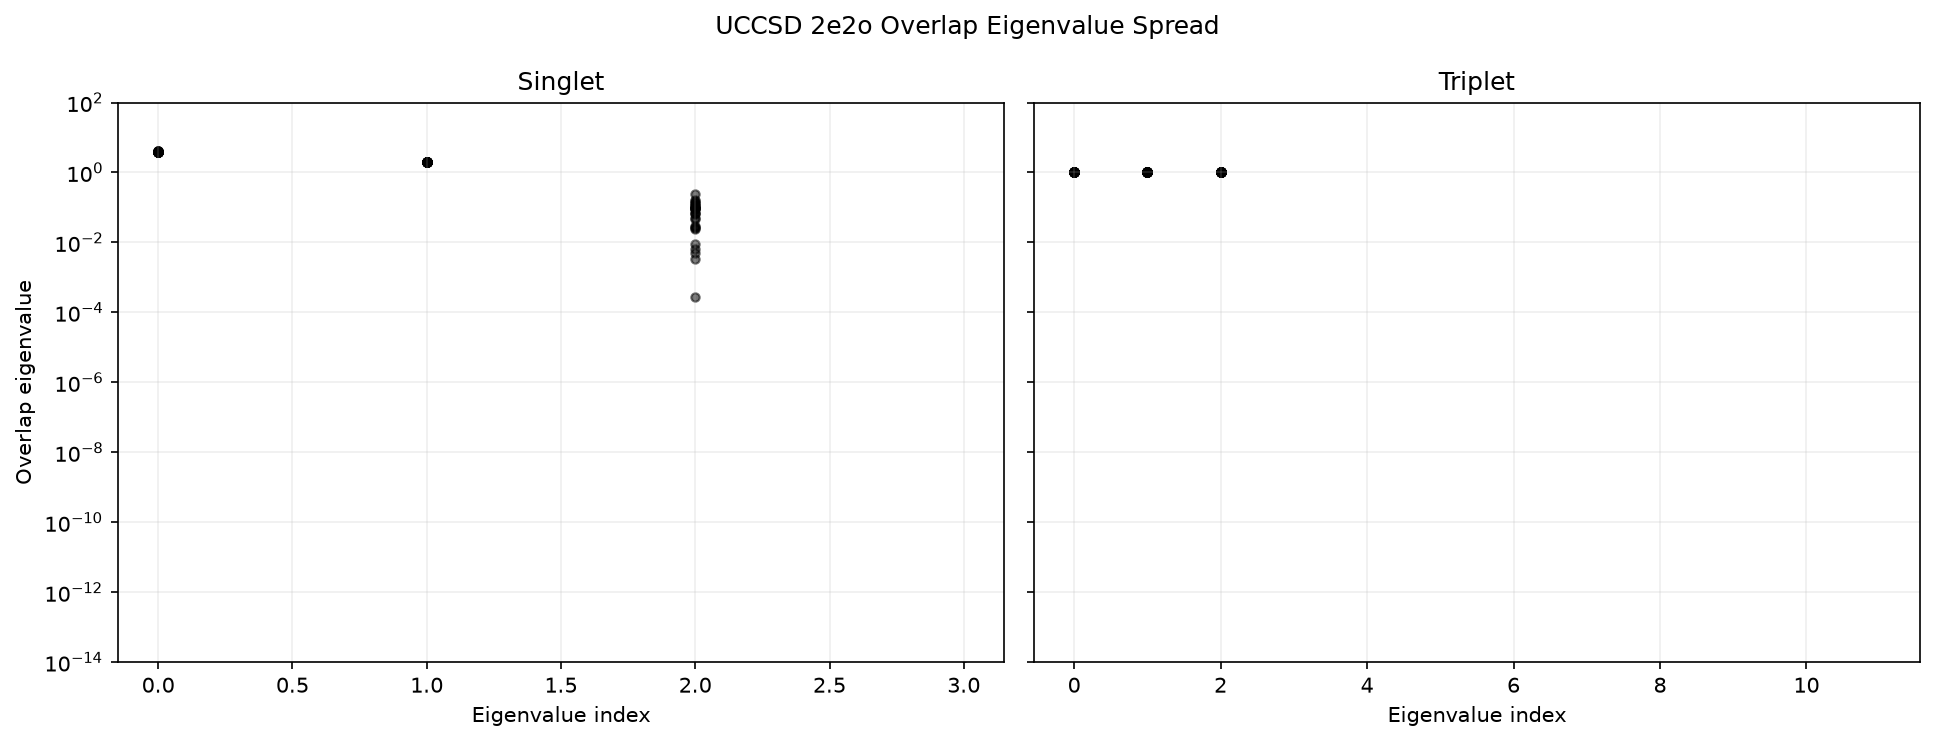
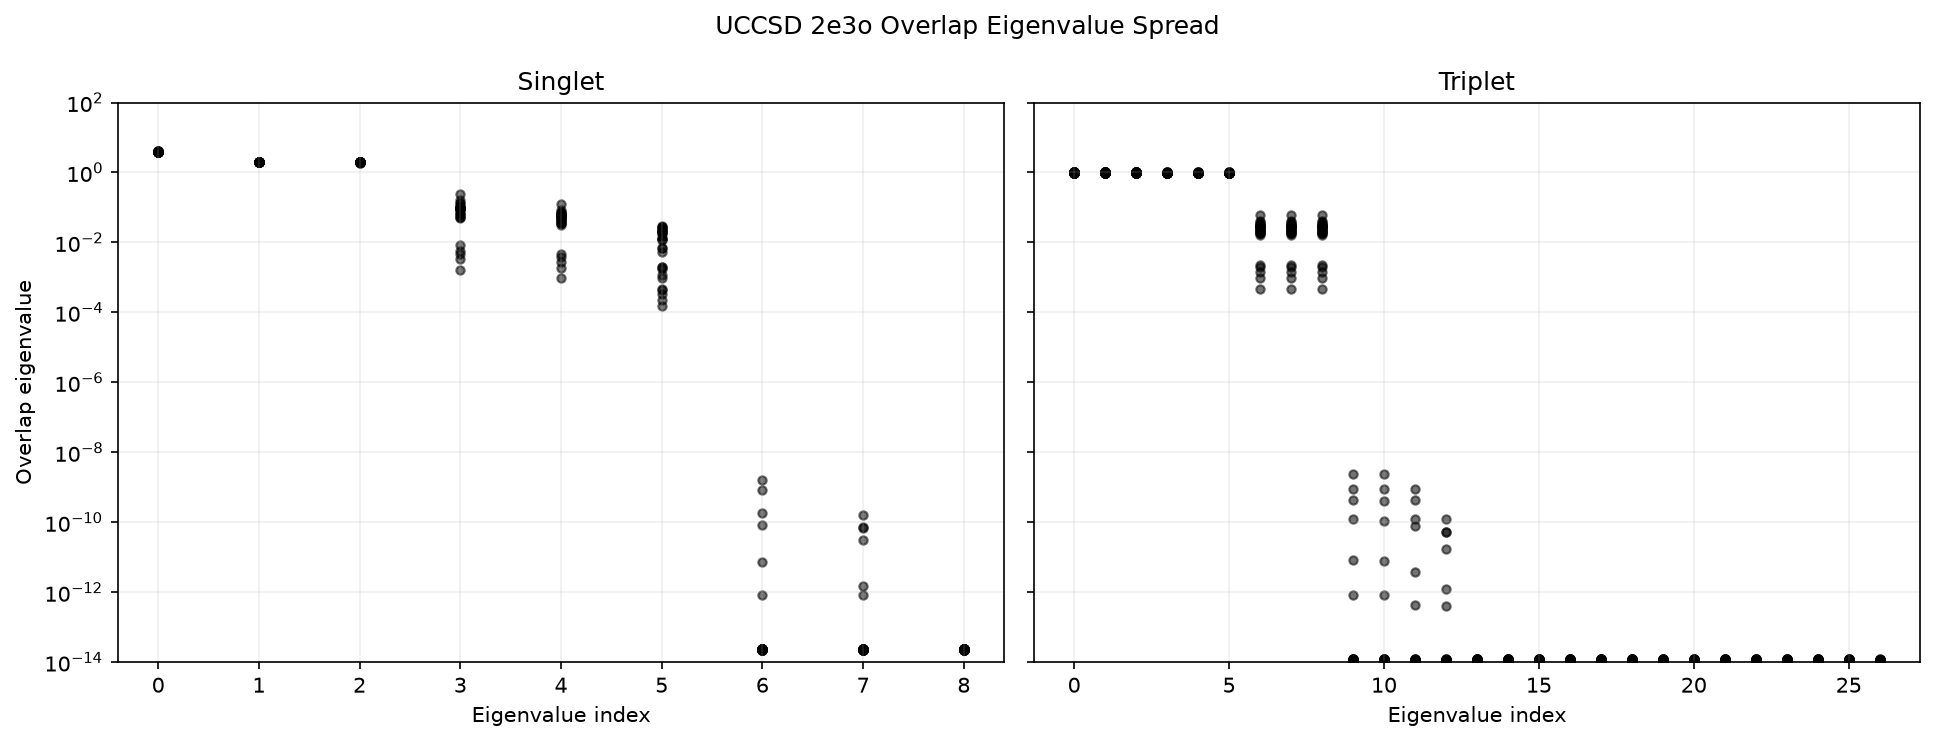
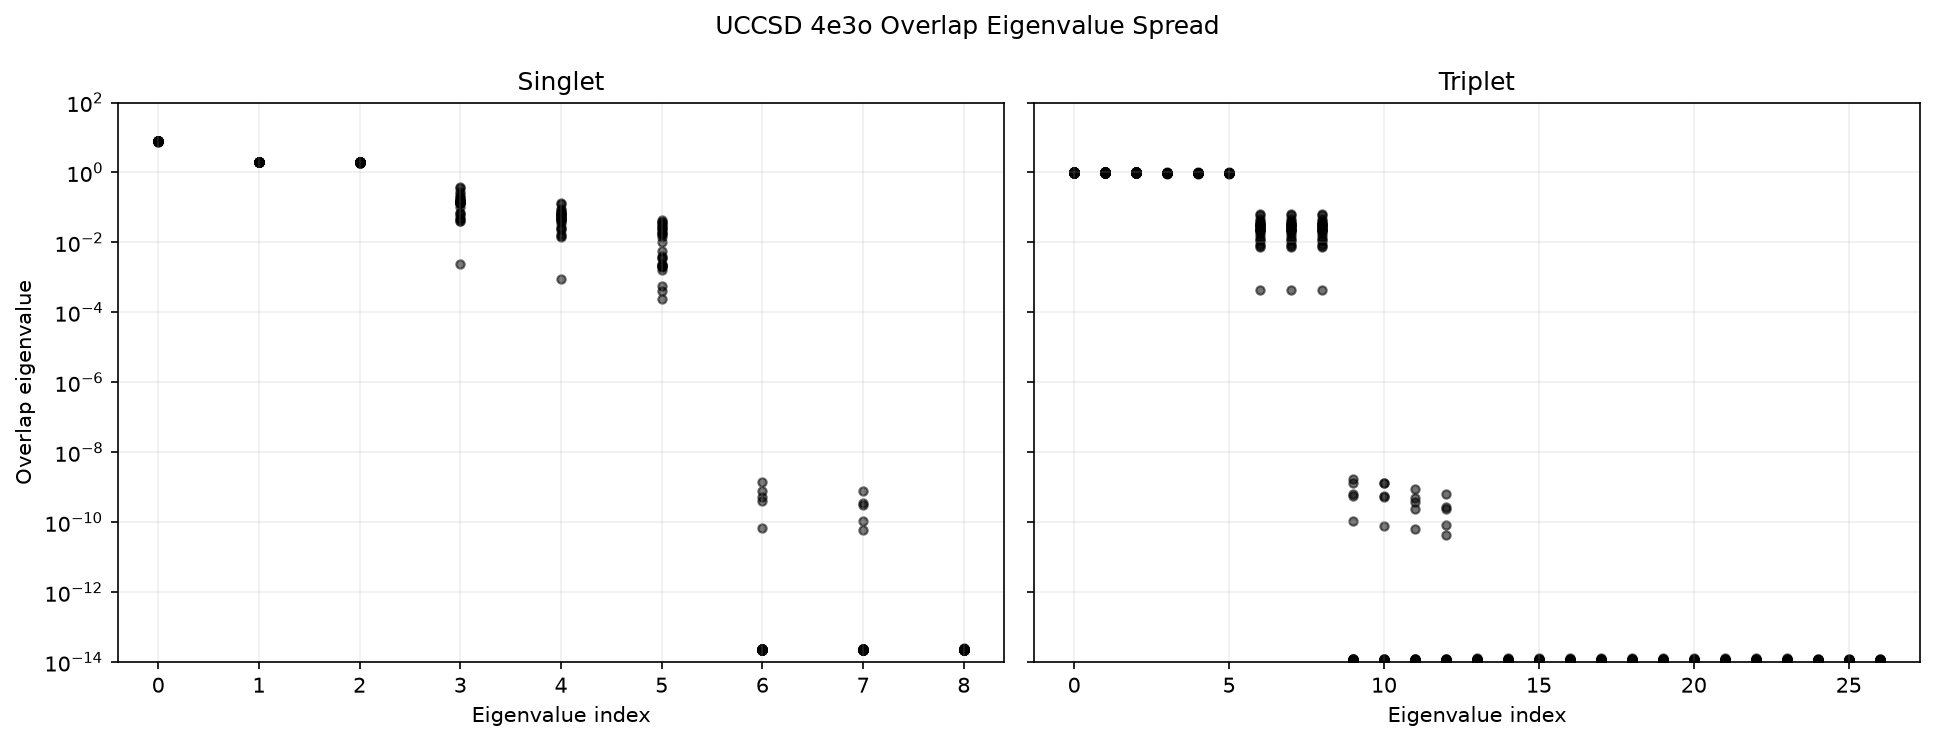
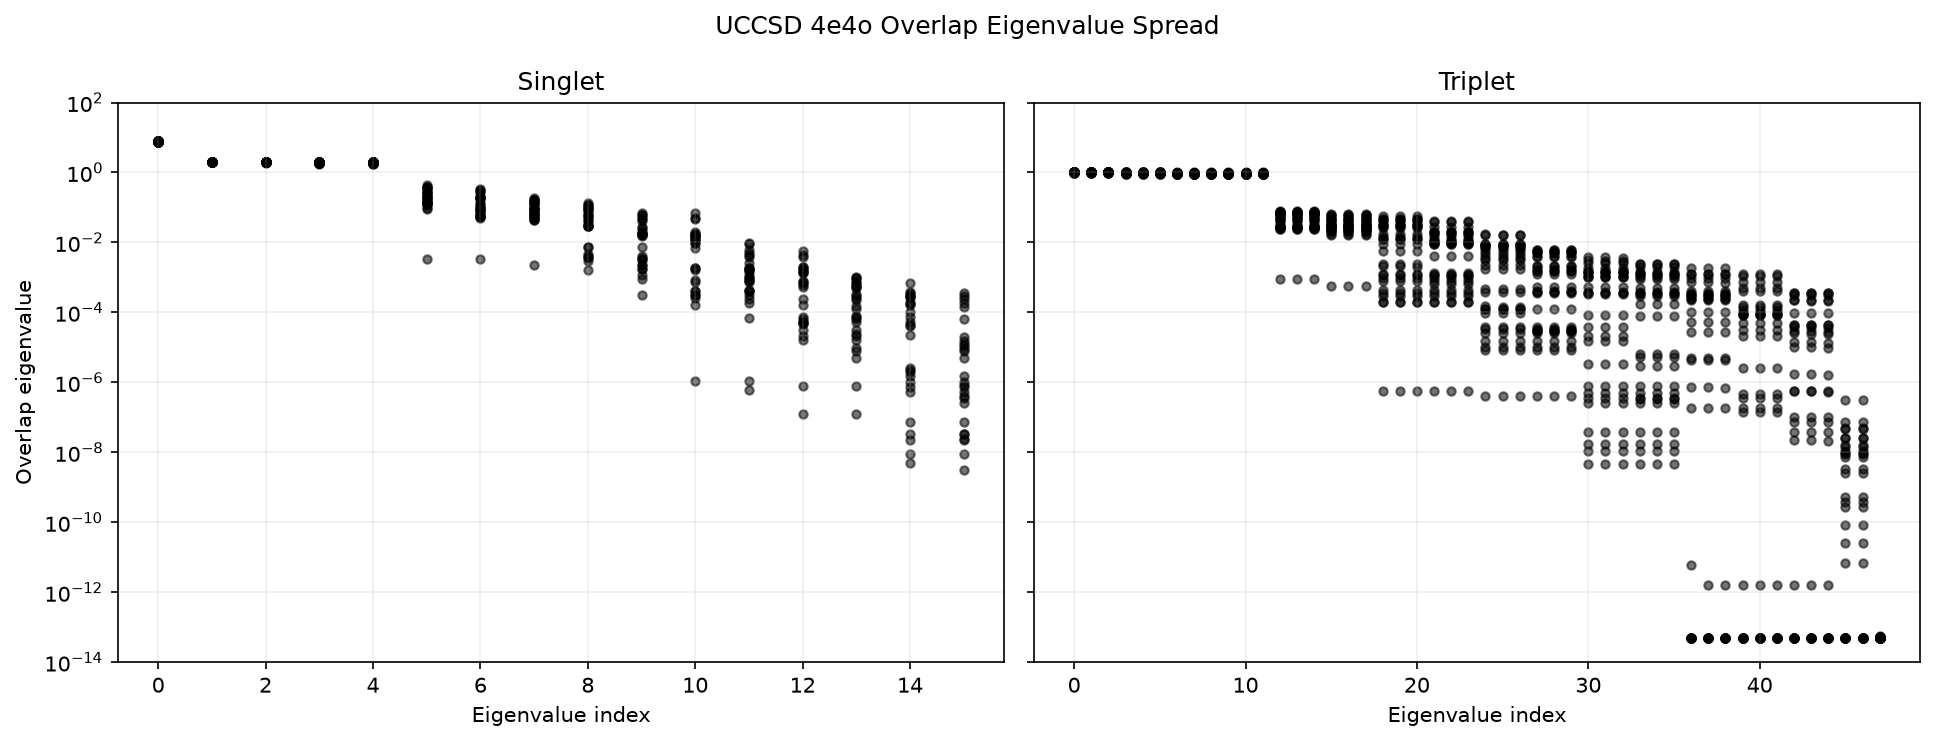
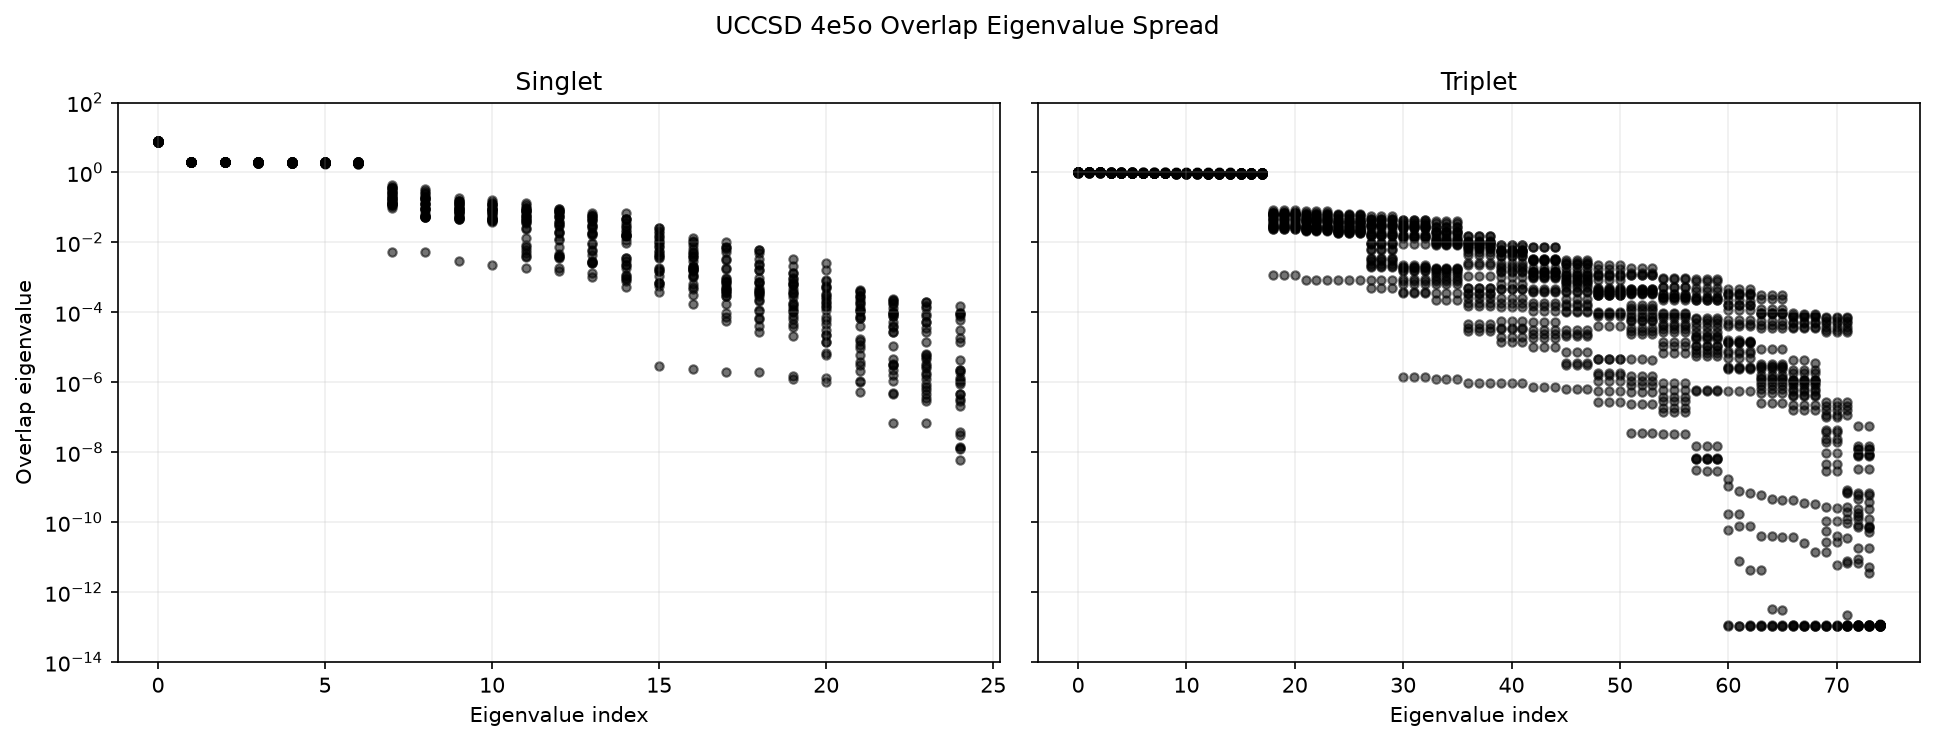
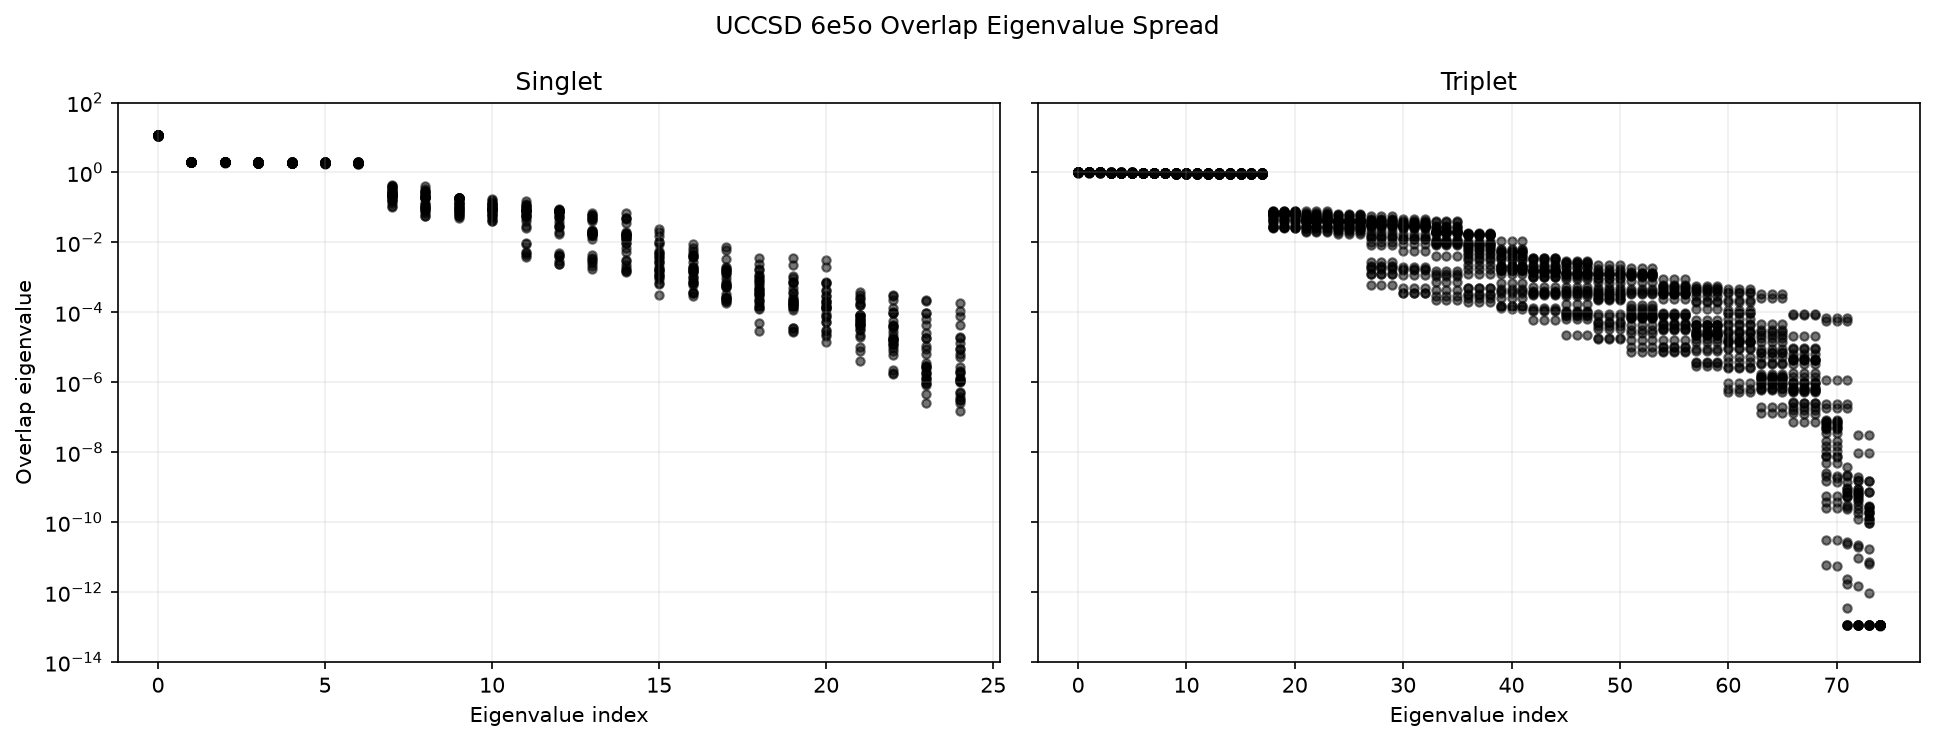
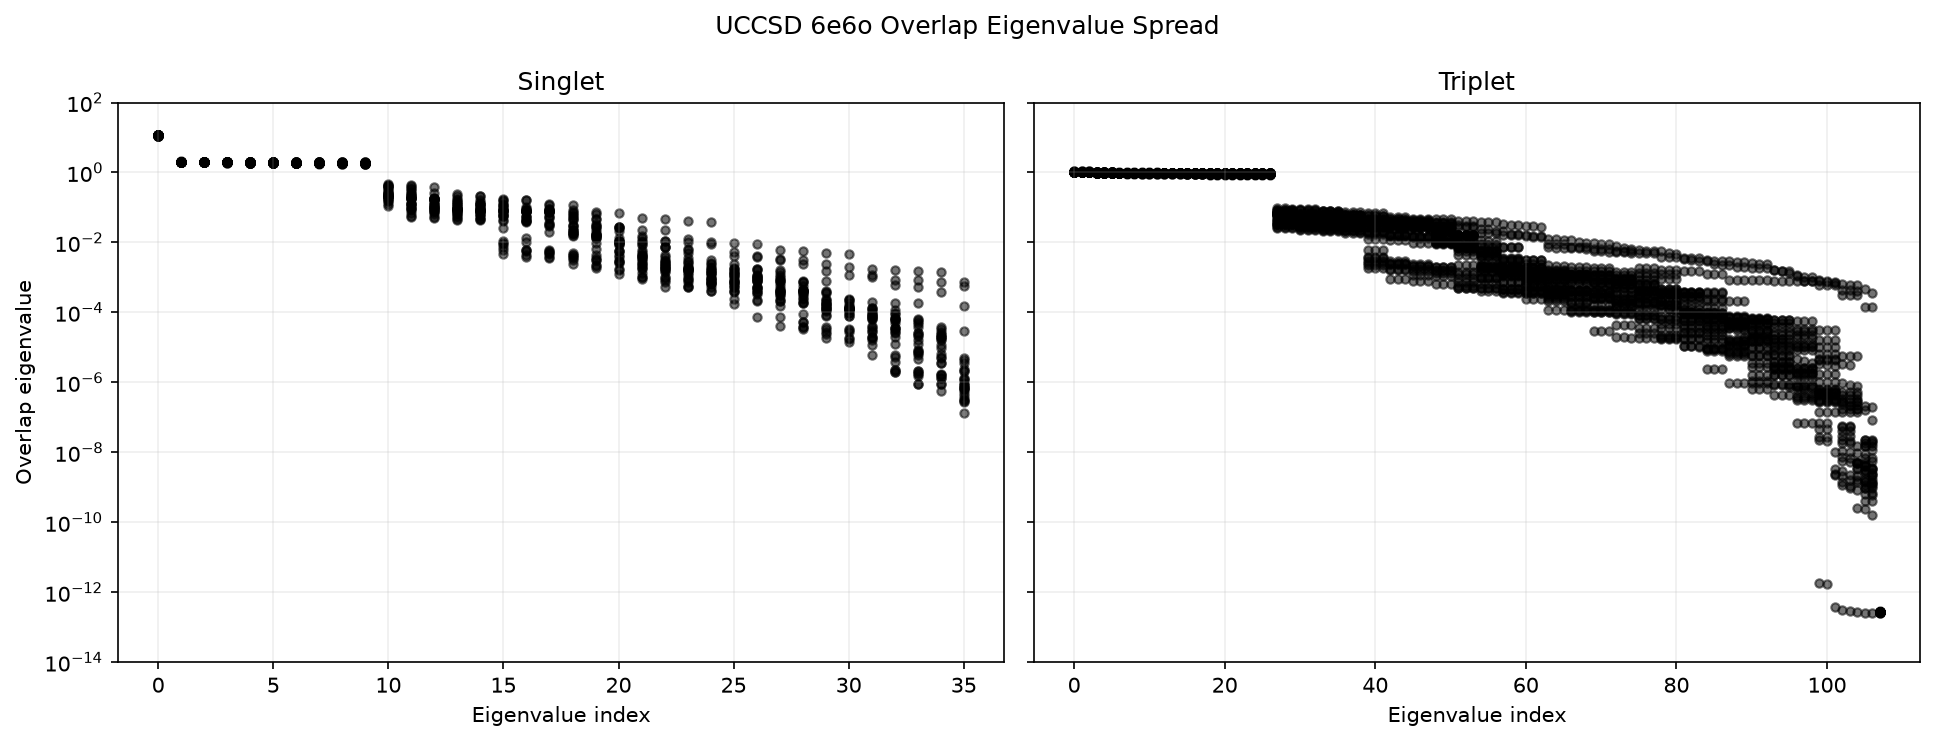
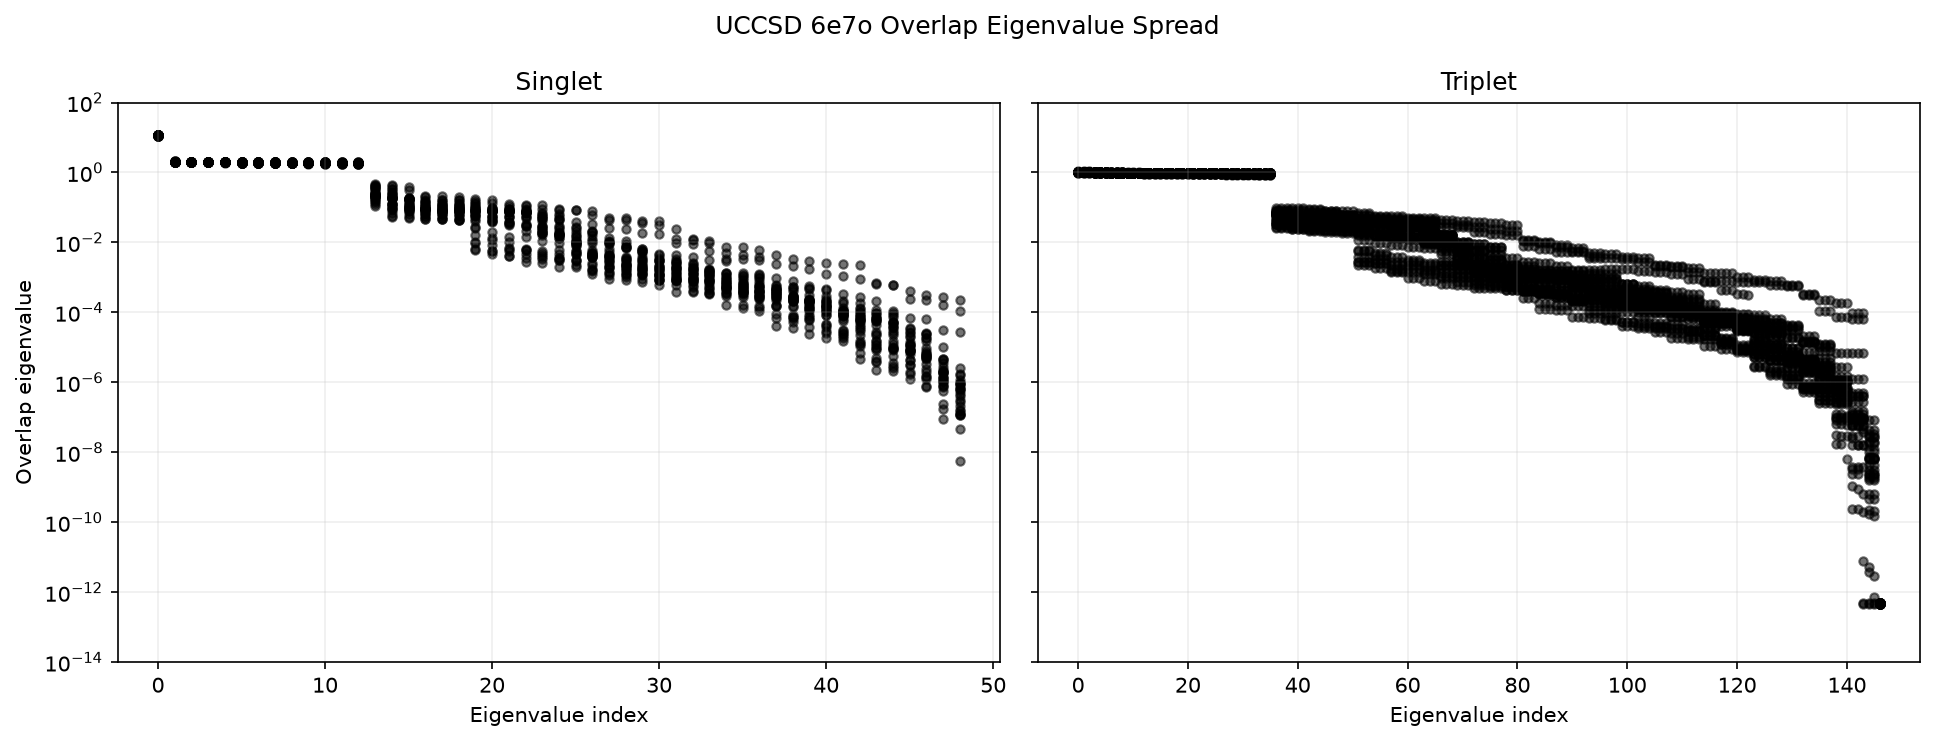
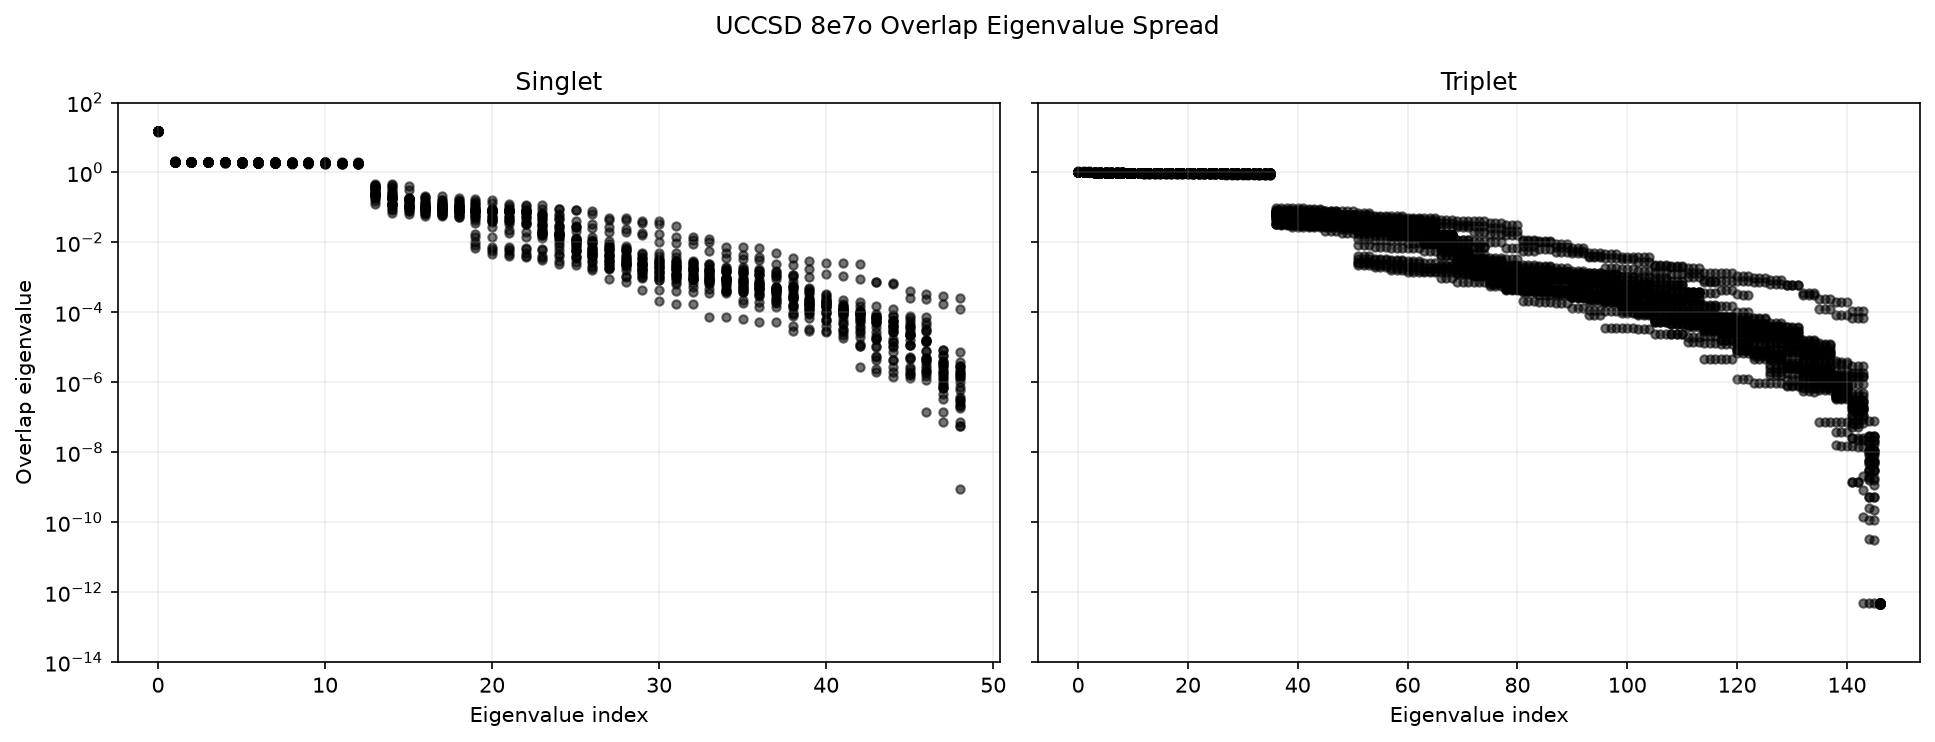
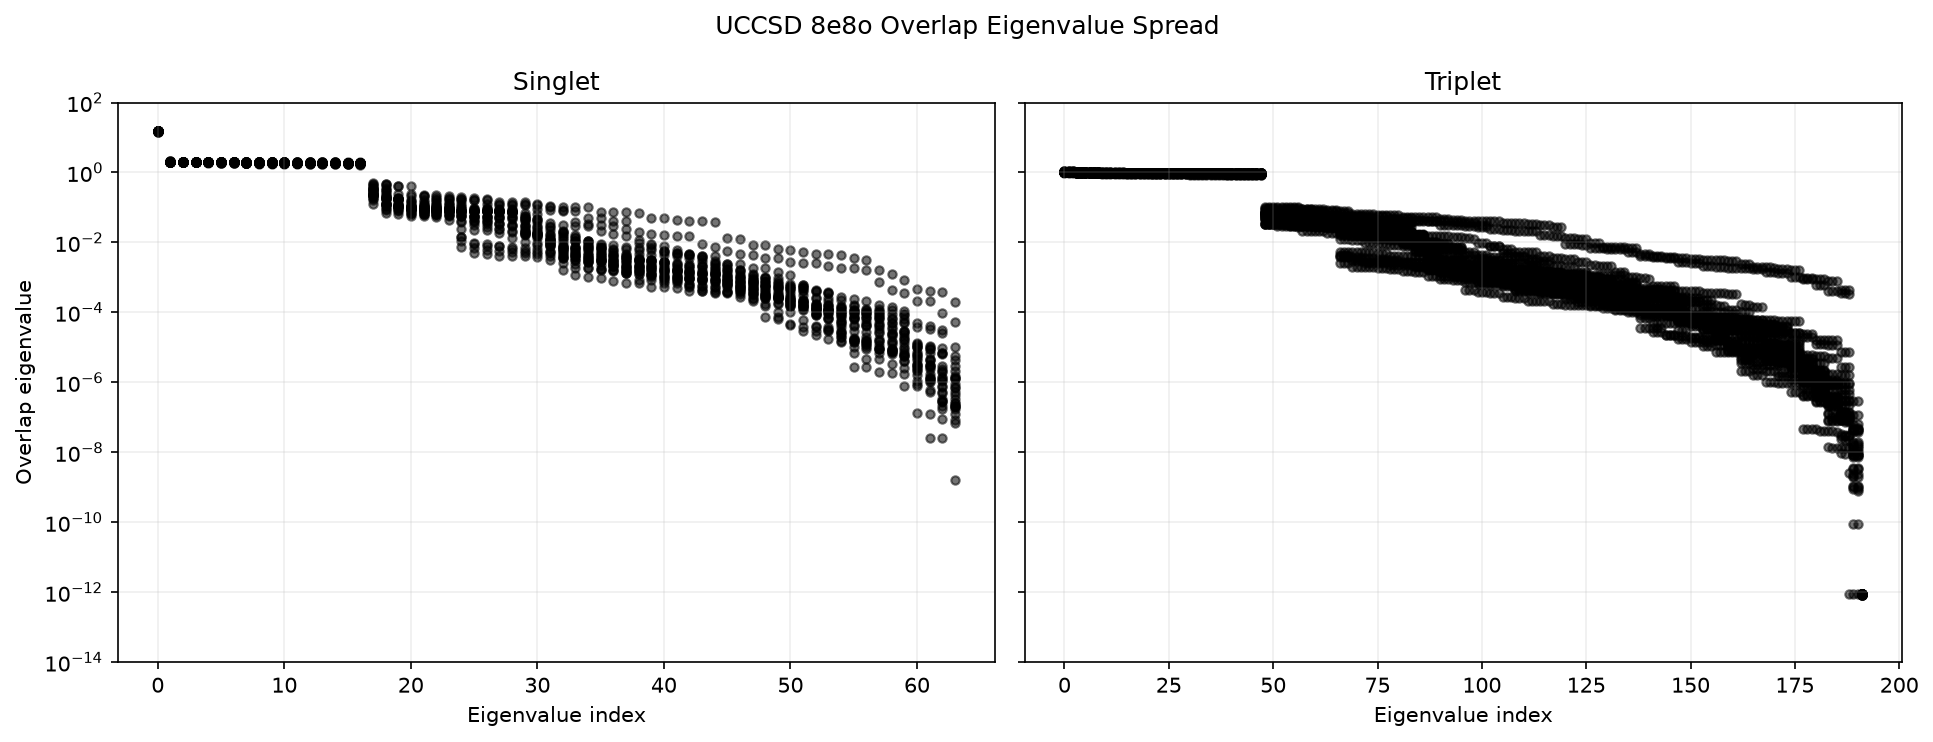

In [2]:
# For UCCCSD, record the eigenvalue spread
df_uccsd = df_sv[df_sv["ansatz"] == "UCCSD"]
active_spaces = sorted(df_uccsd["active_space"].unique(), key=parse_active_space)
uccsd_eigenvalue_data = {}
uccsd_eigenvalue_figures = []

# Separate by active spaces
for active_space in active_spaces:
    df_uccsd_active = df_uccsd[df_uccsd["active_space"] == active_space]
    eigenvalue_data = {}

    for expansion in ("singlet", "triplet"):
        # Get unique df for each expansion type
        df_expansion = df_uccsd_active[df_uccsd_active["expansion"] == expansion]
        points = []

        # Diagonalise S and record eigenvalues
        for S in df_expansion["S"]:
            eigenvalues = la.eigvalsh(np.asarray(S, dtype=complex)).real[::-1]
            points.extend(enumerate(eigenvalues))

        eigenvalue_data[expansion] = points

    uccsd_eigenvalue_data[active_space] = eigenvalue_data
    figure = plot_spin_eigenvalue_spread(eigenvalue_data, active_space)
    save_figure(figure, "dimension_analysis/overlap_eigenvalue_spread", f"uccsd_{active_space}")
    uccsd_eigenvalue_figures.append(figure)

show_scrollable_figs(uccsd_eigenvalue_figures)



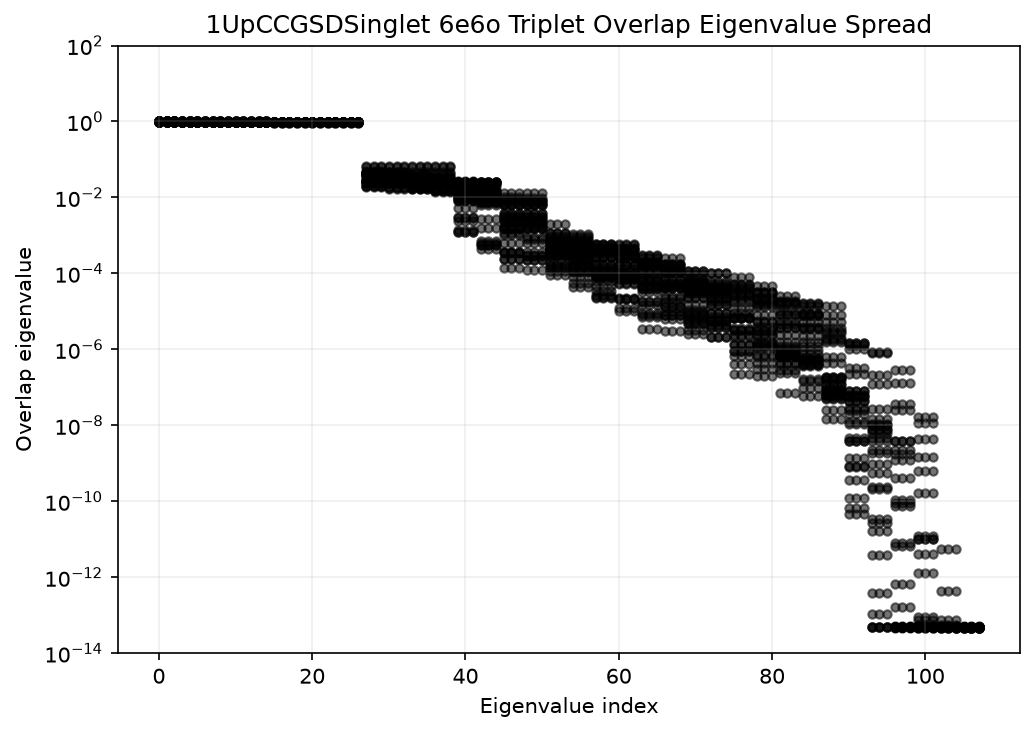

In [3]:
# Repeat above cell but for paired ansatz, triplets only 
df_1up = df_sv[
    (df_sv["ansatz"] == "1UpCCGSDSinglet")
    & (df_sv["active_space"] == "6e6o")
]
one_up_active_spaces = ["6e6o"]
one_up_triplet_eigenvalue_data = {}
one_up_triplet_eigenvalue_figures = []

for active_space in one_up_active_spaces:
    df_1up_triplet = df_1up[
        (df_1up["active_space"] == active_space)
        & (df_1up["expansion"] == "triplet")
    ]
    points = []

    for S in df_1up_triplet["S"]:
        eigenvalues = la.eigvalsh(np.asarray(S, dtype=complex)).real[::-1]
        points.extend(enumerate(eigenvalues))

    one_up_triplet_eigenvalue_data[active_space] = points
    figure = plot_triplet_eigenvalue_spread(points, active_space)
    save_figure(figure, "dimension_analysis/overlap_eigenvalue_spread", f"1upccgsdsinglet_triplet_{active_space}")
    one_up_triplet_eigenvalue_figures.append(figure)

show_scrollable_figs(one_up_triplet_eigenvalue_figures)


## Eigenvector decomposition


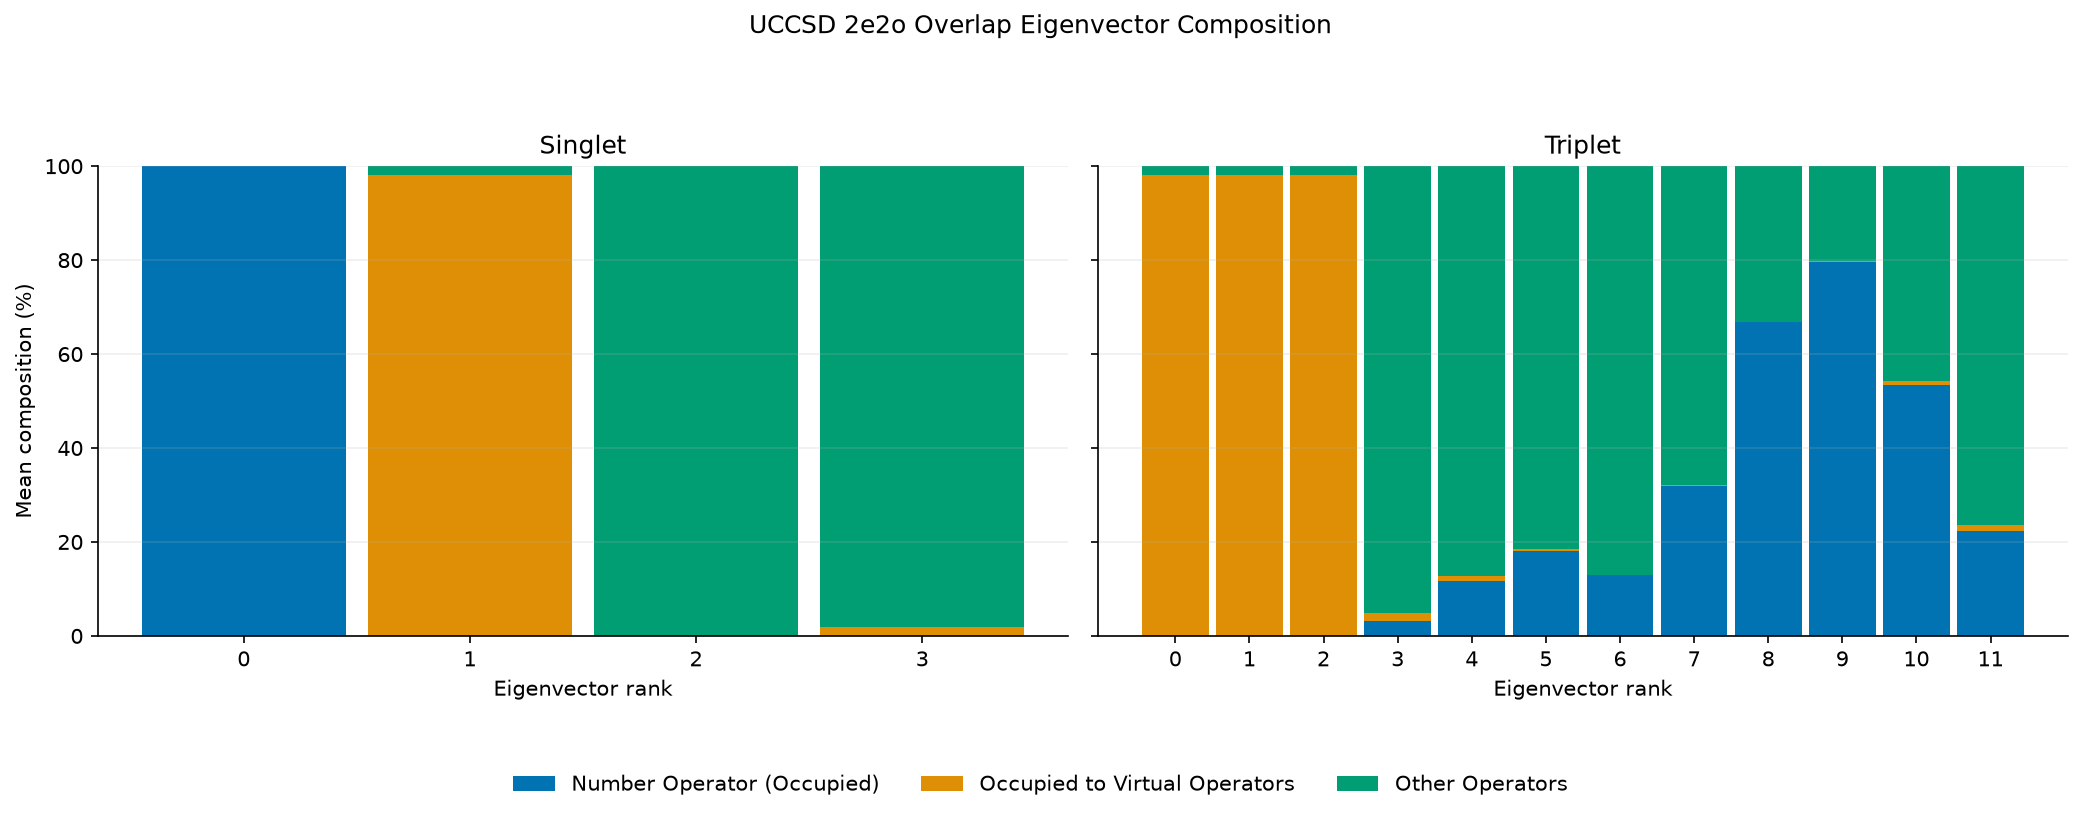
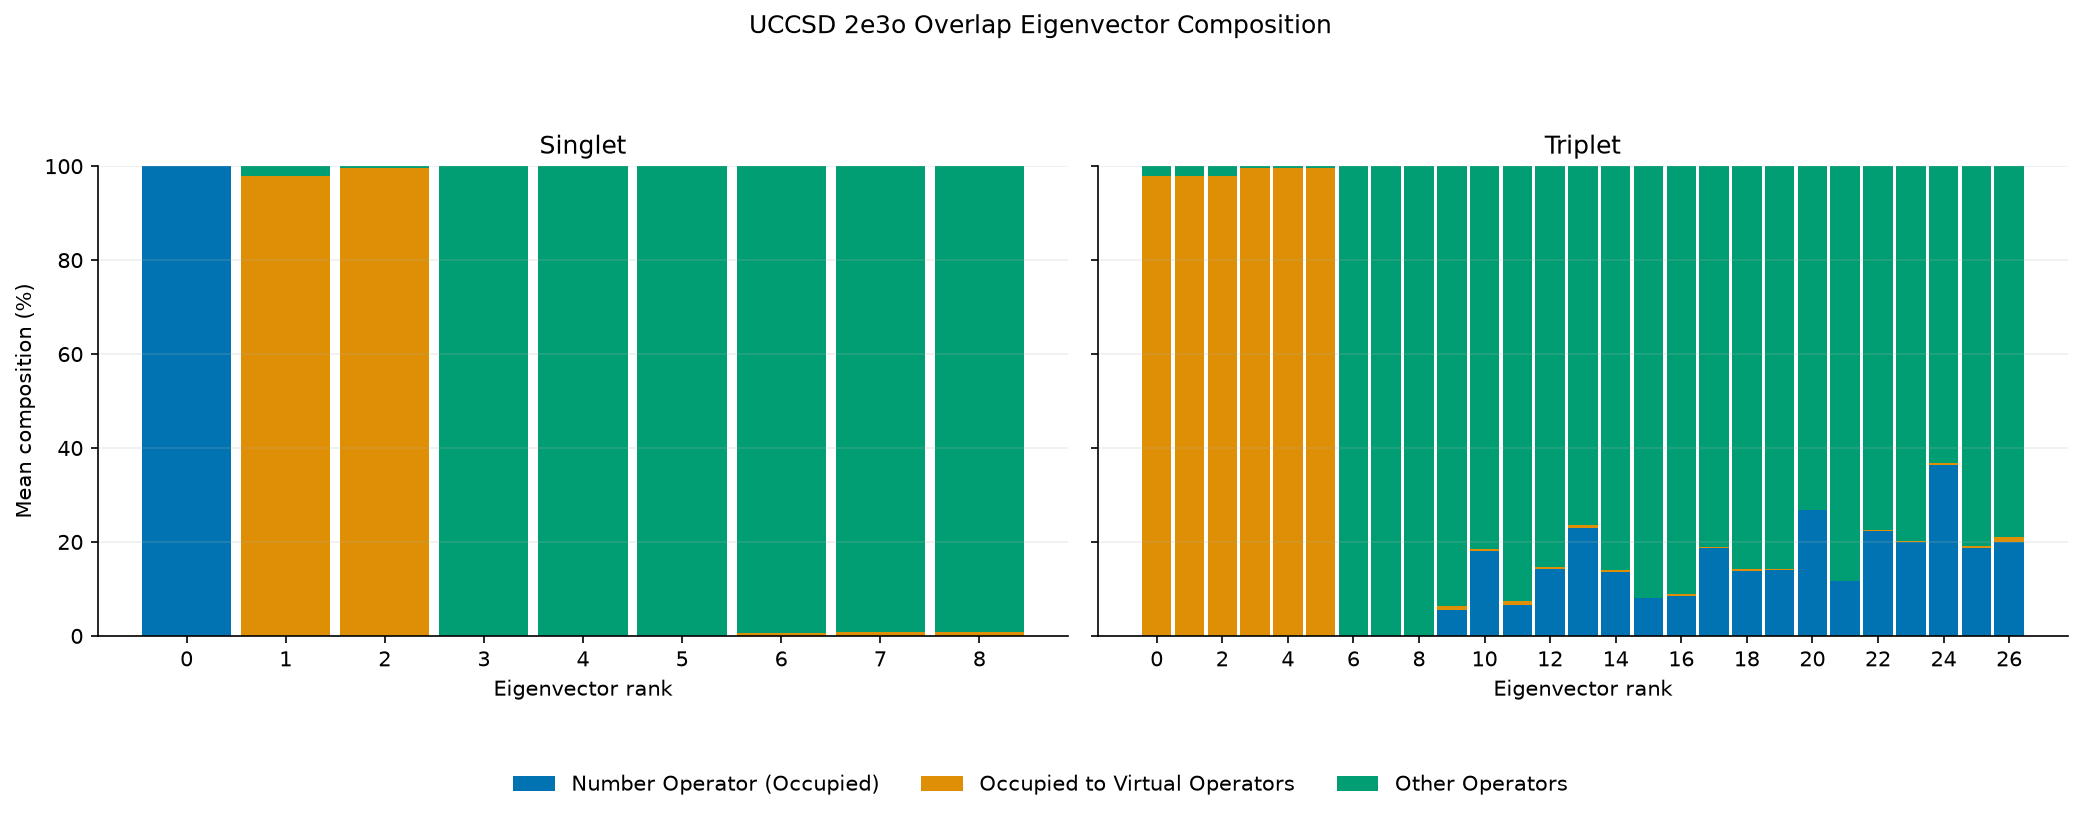
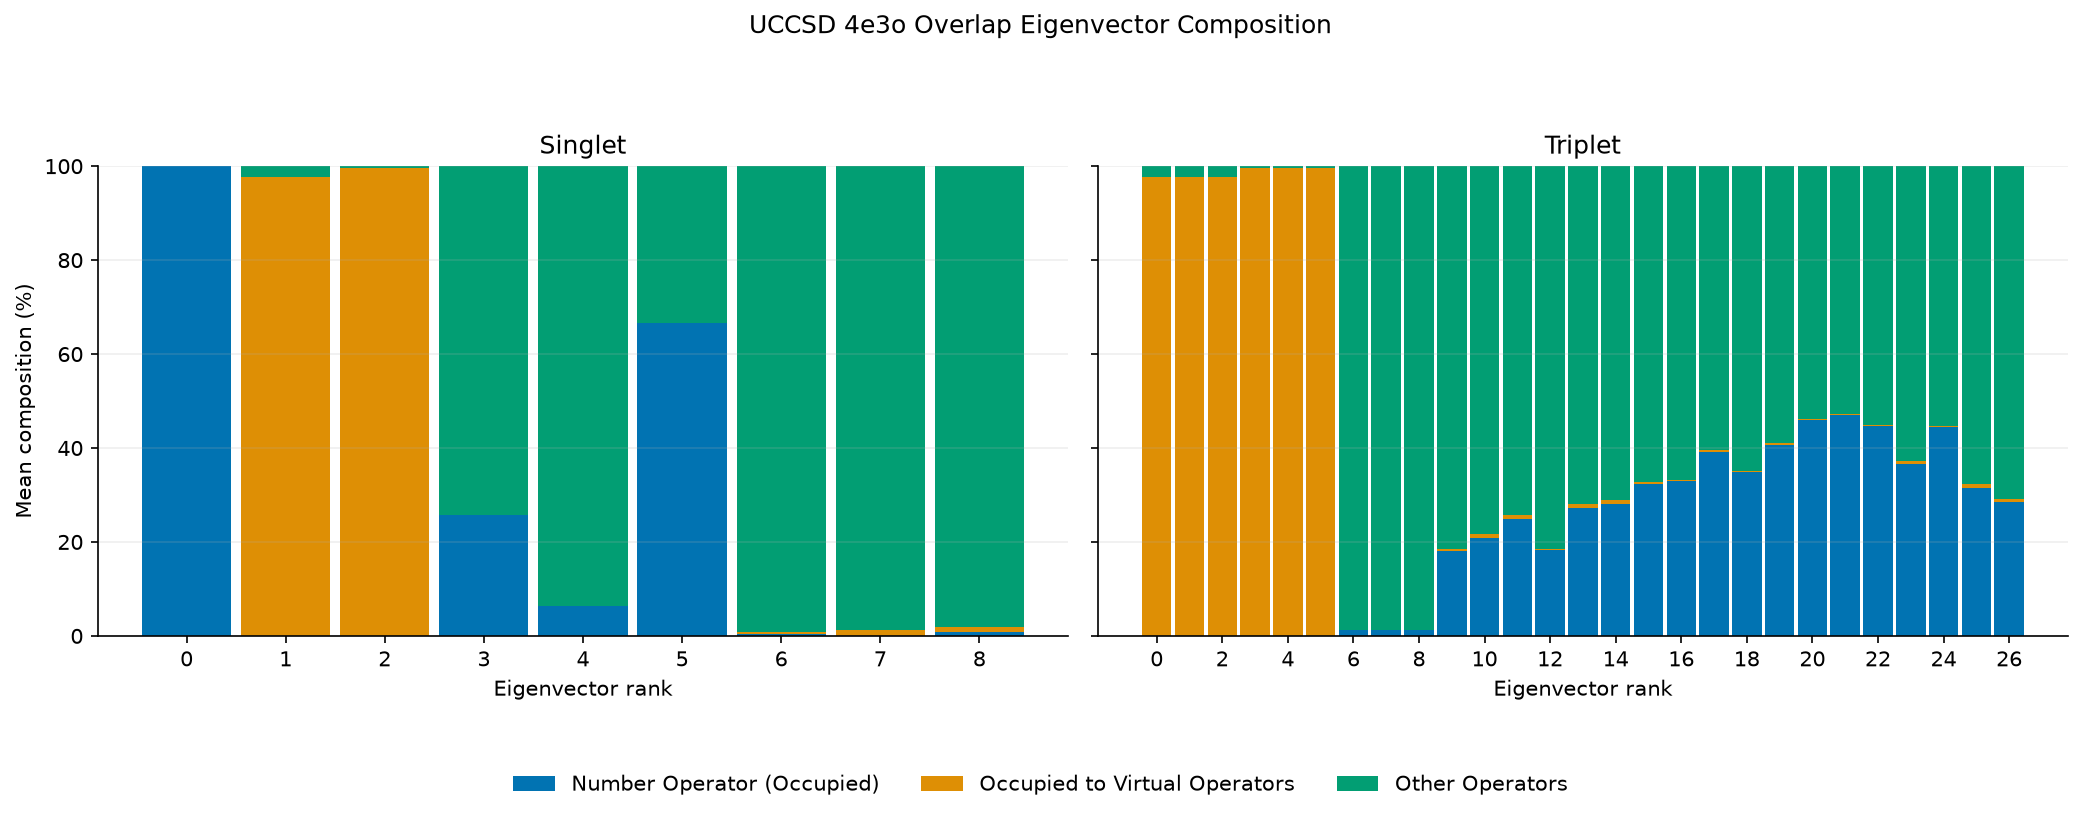
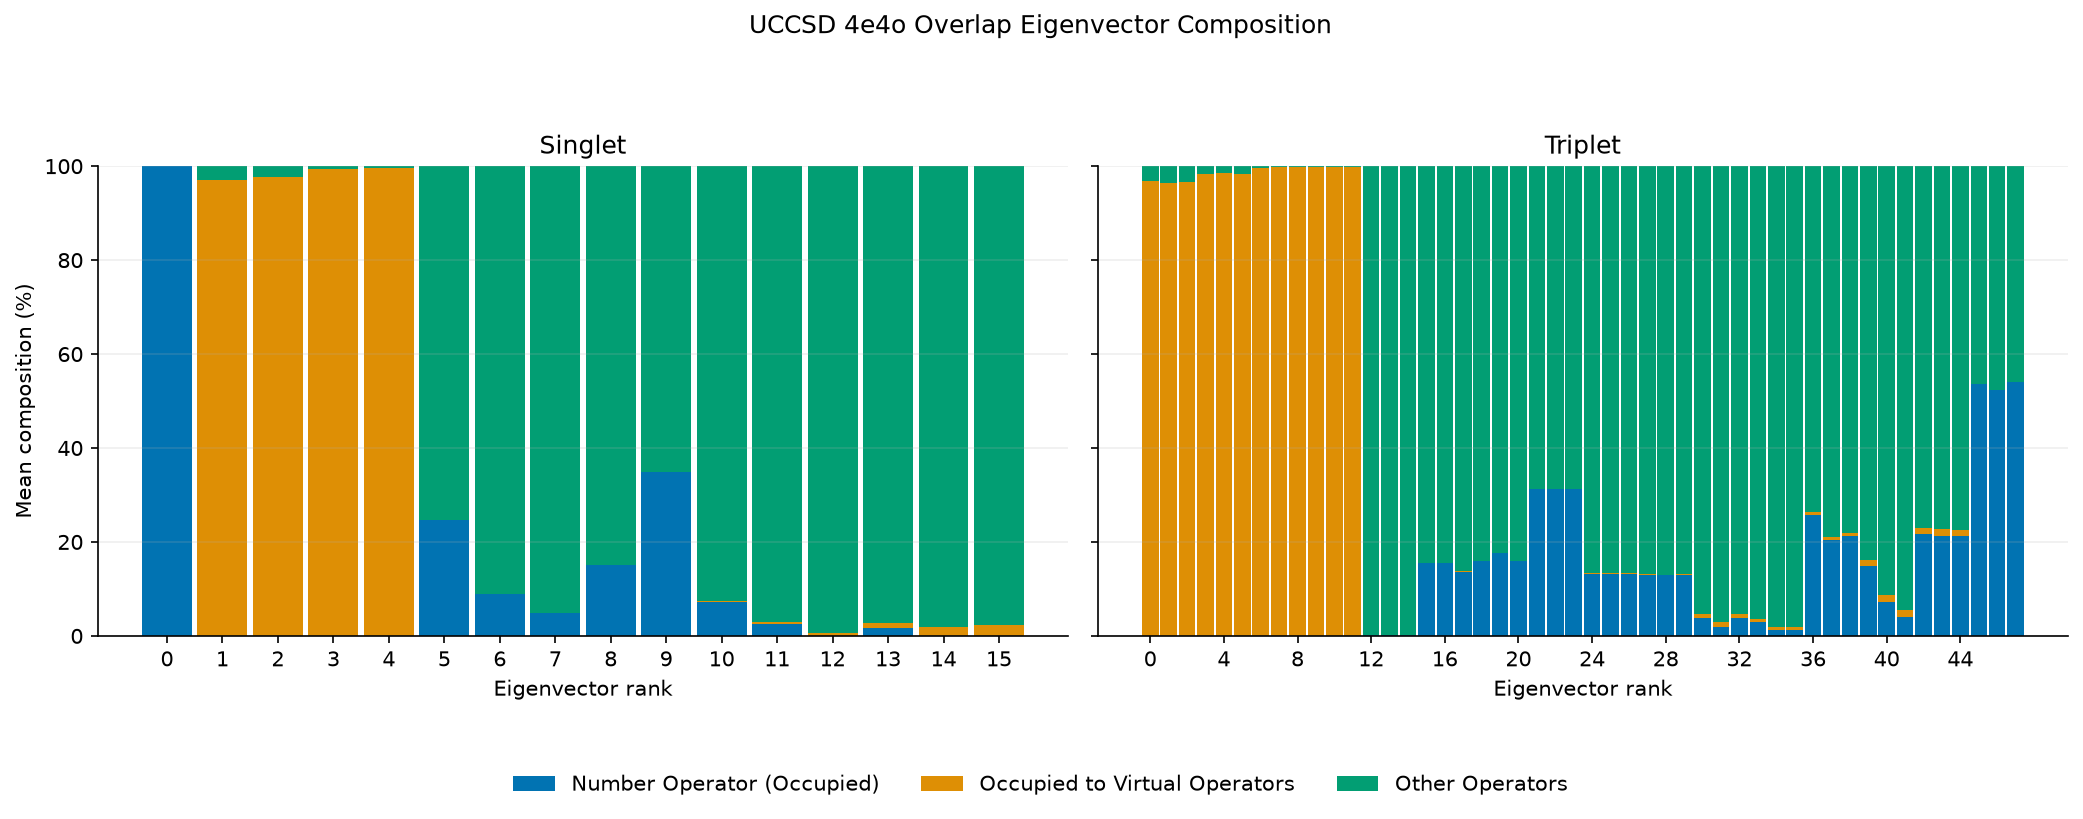
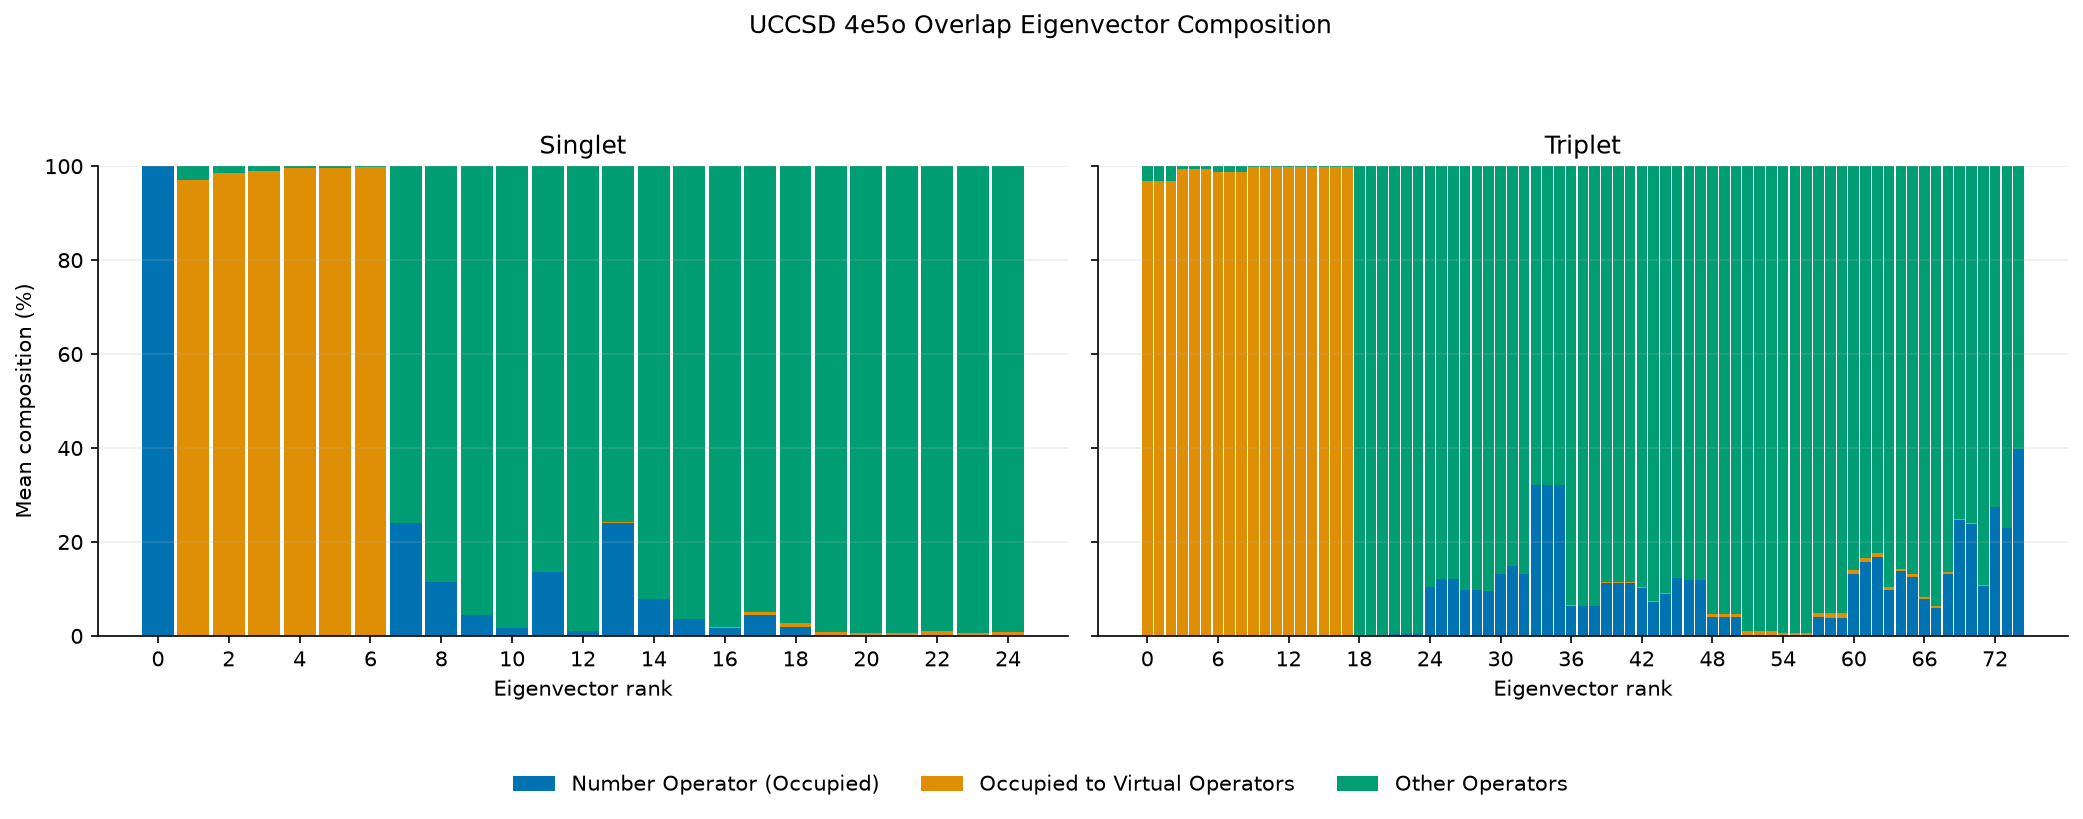
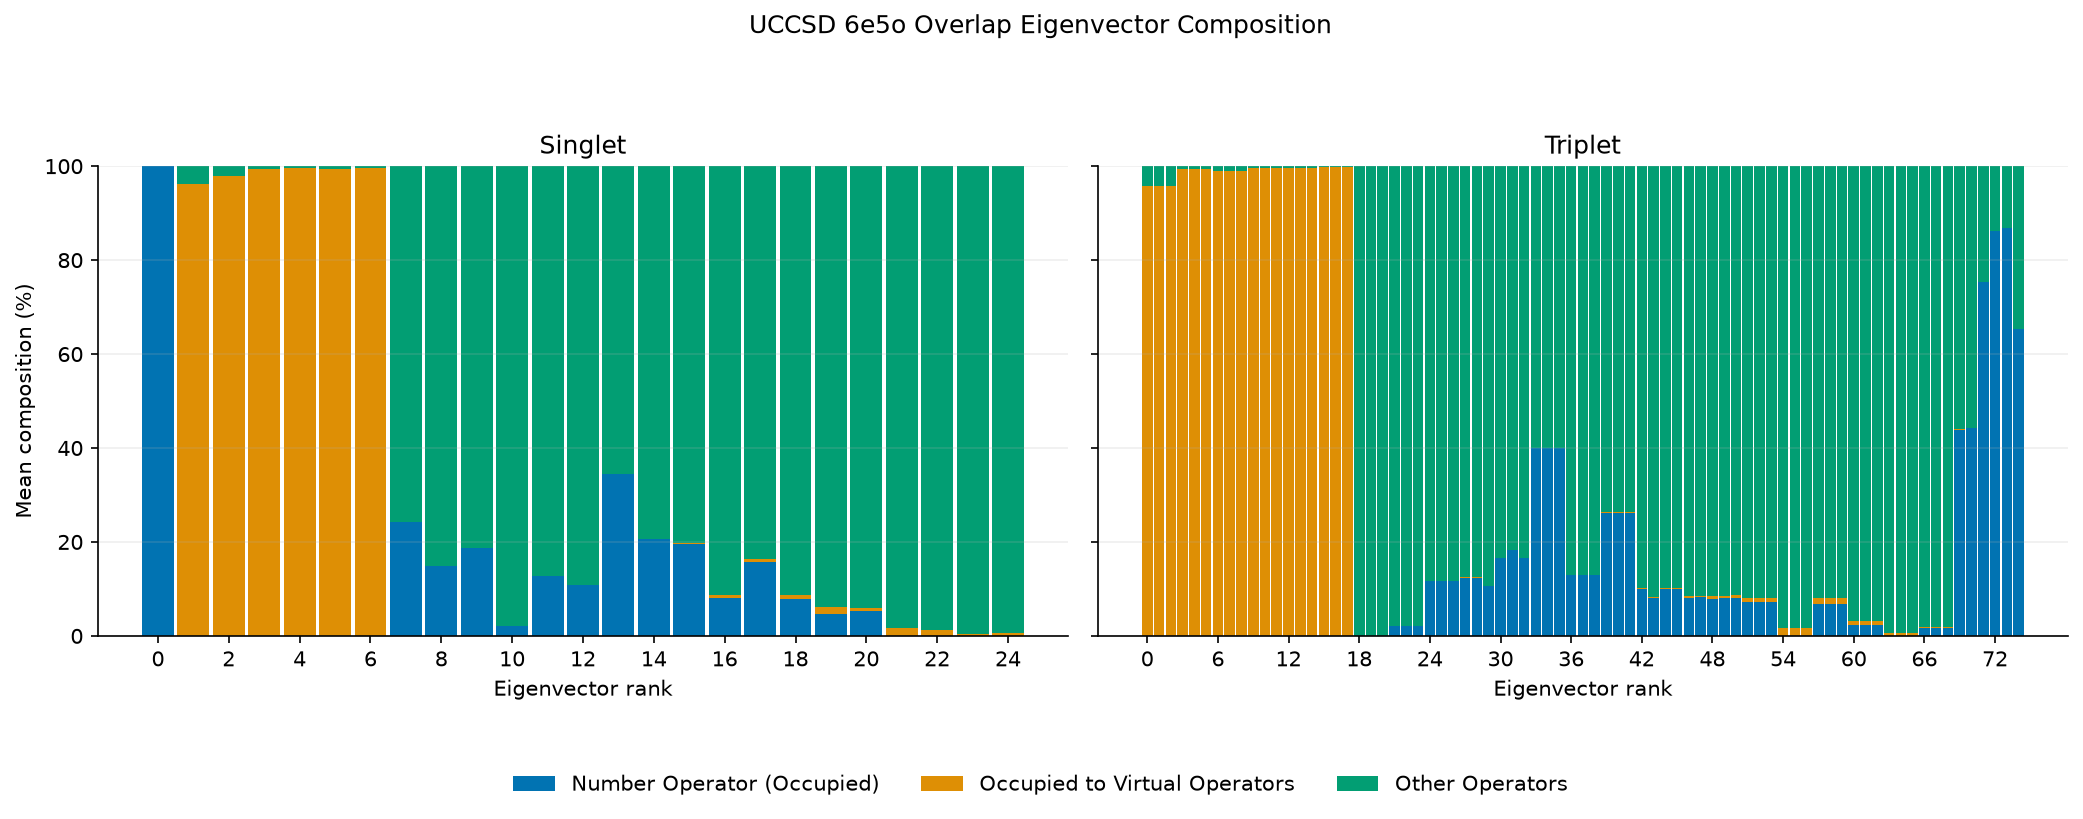
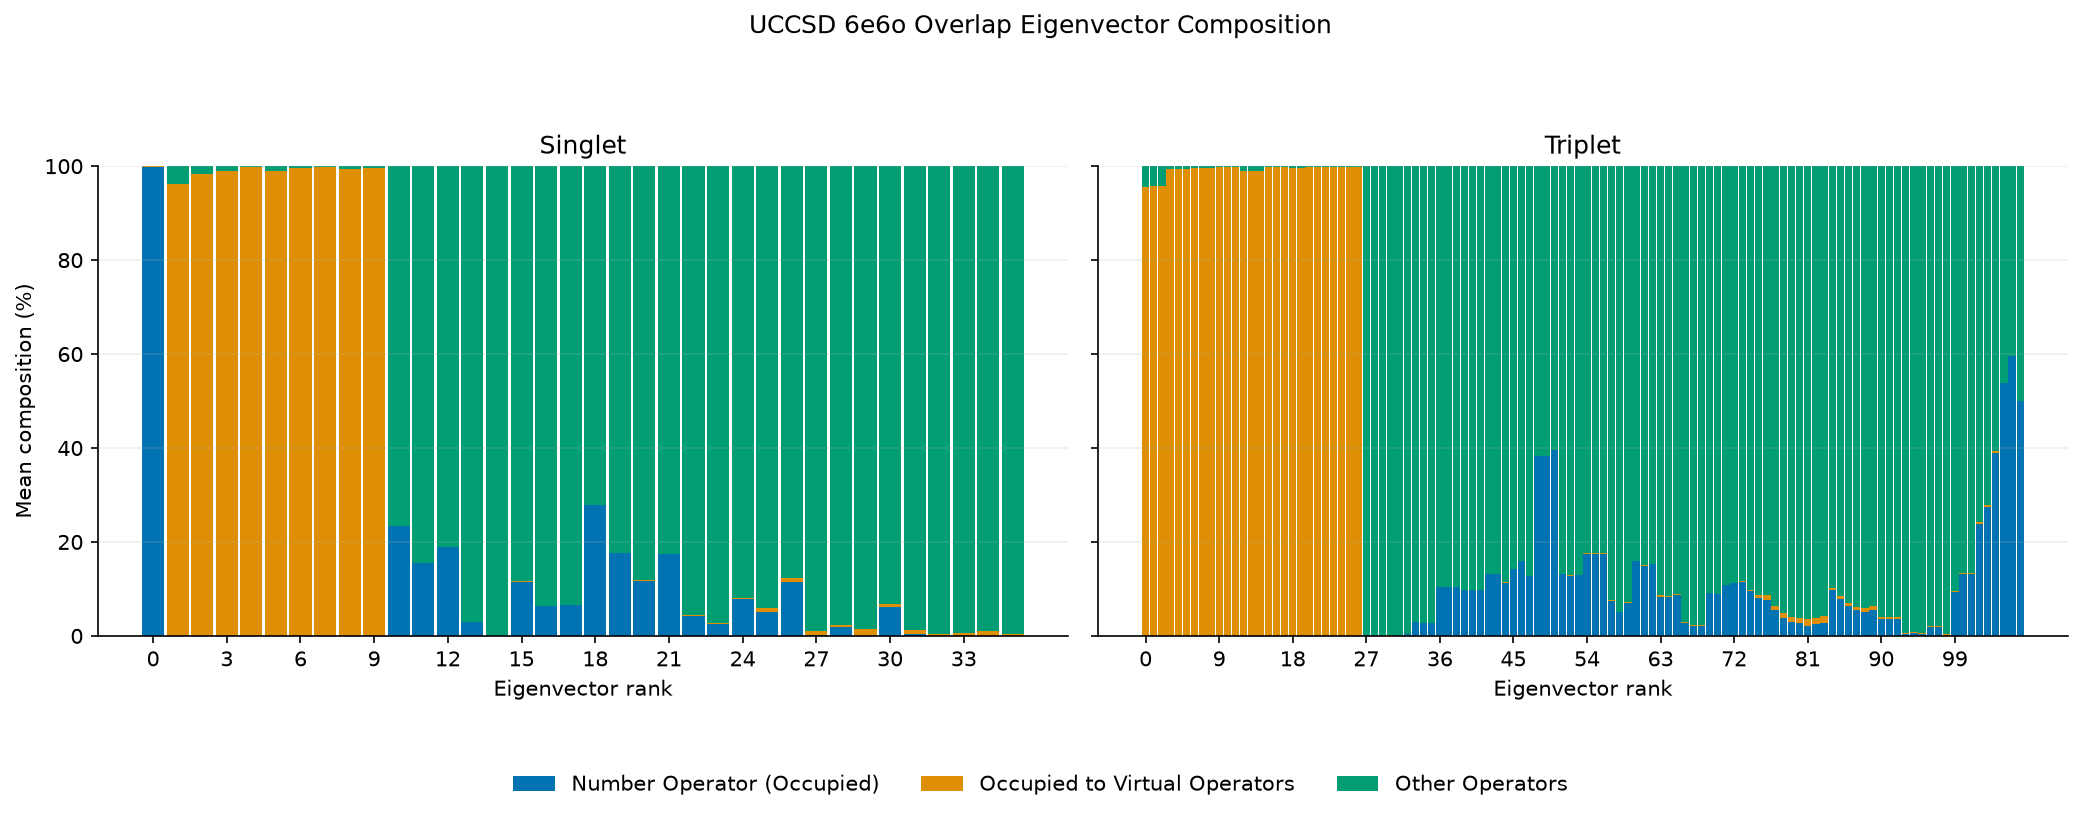
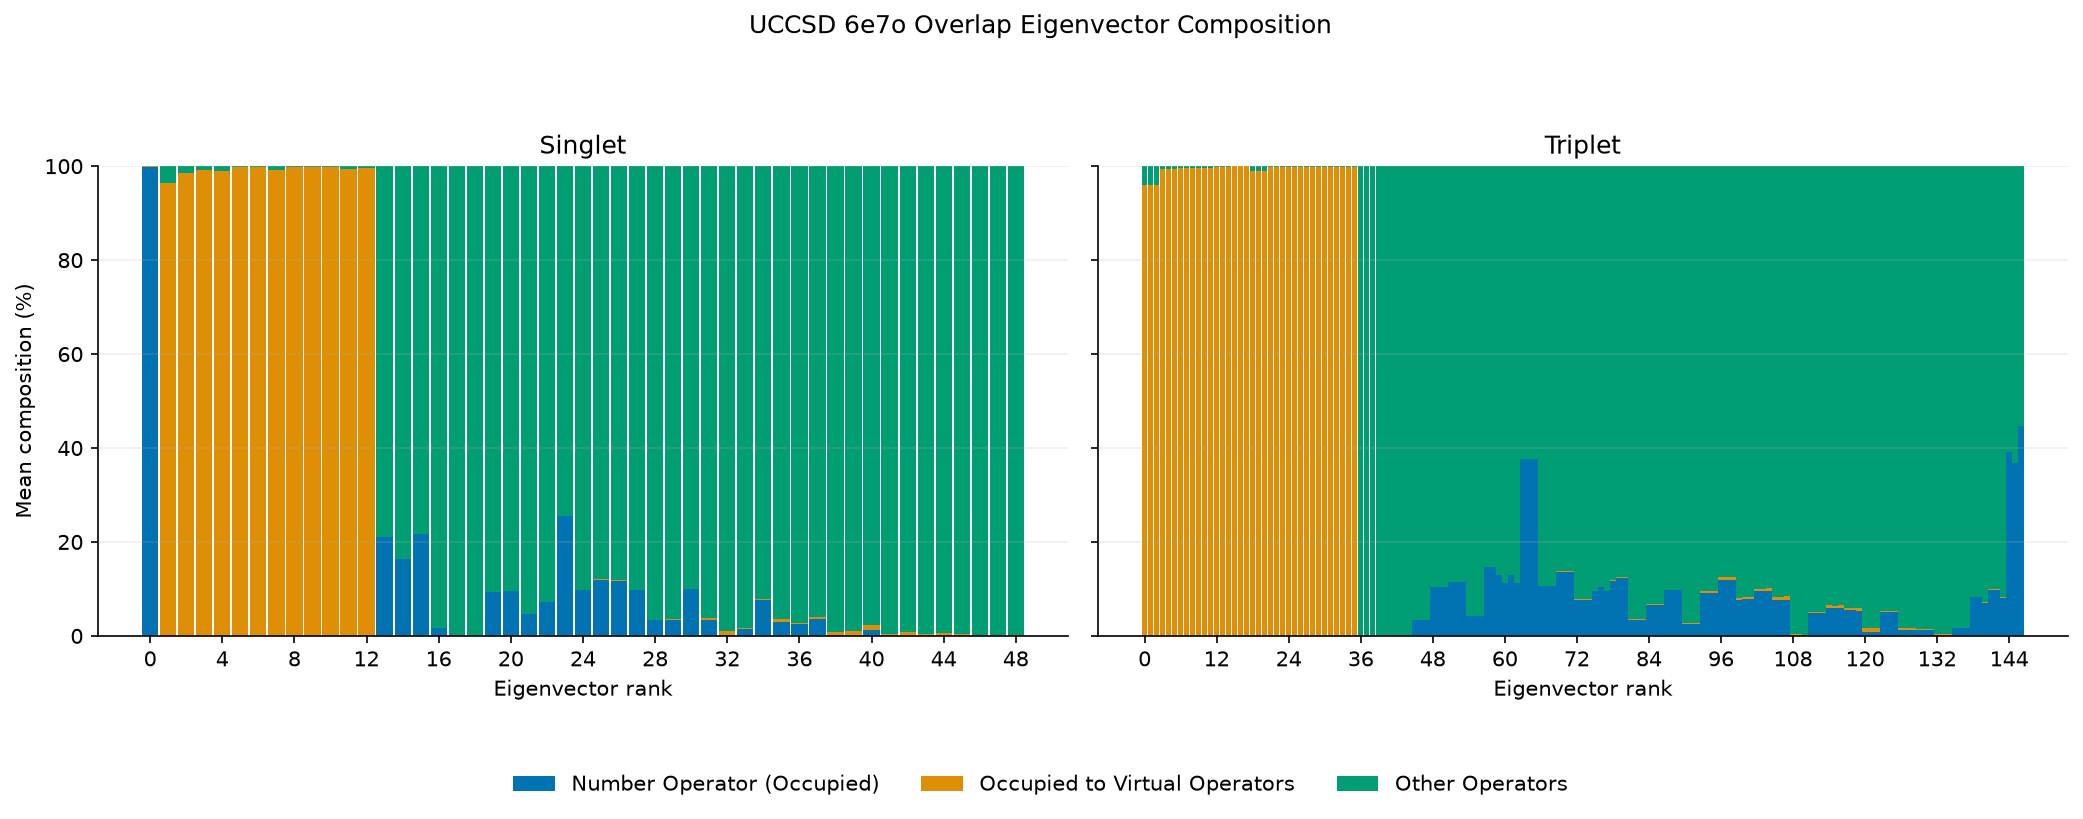
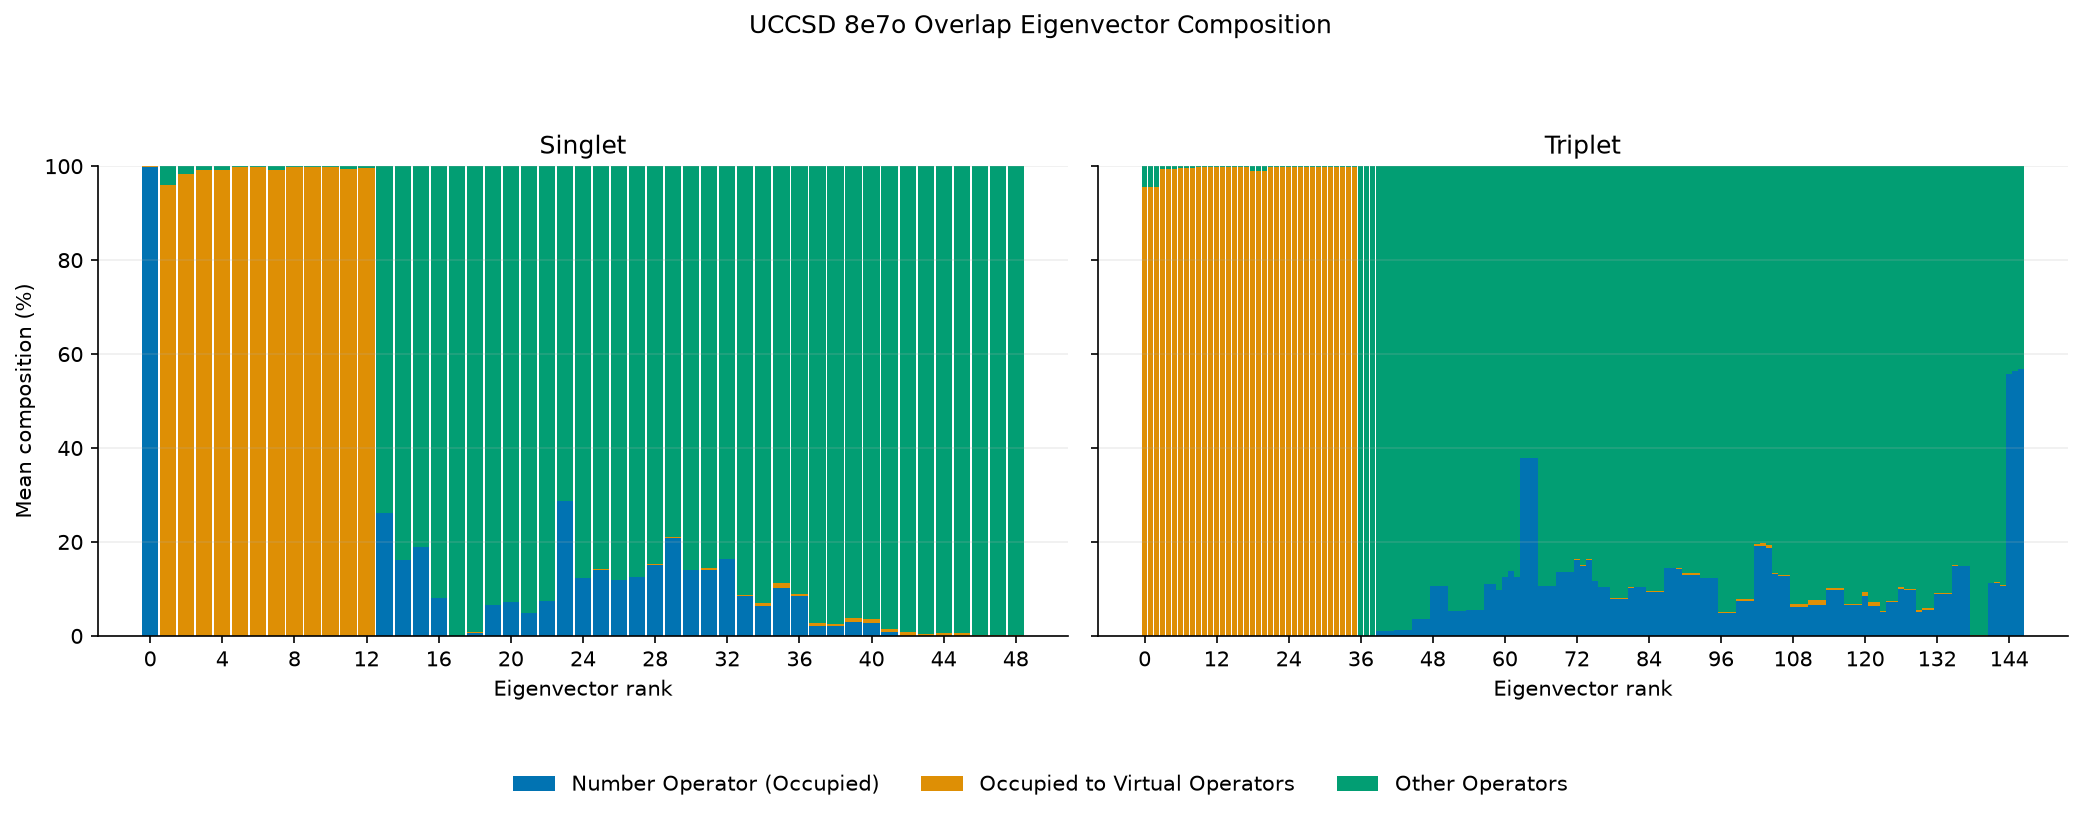
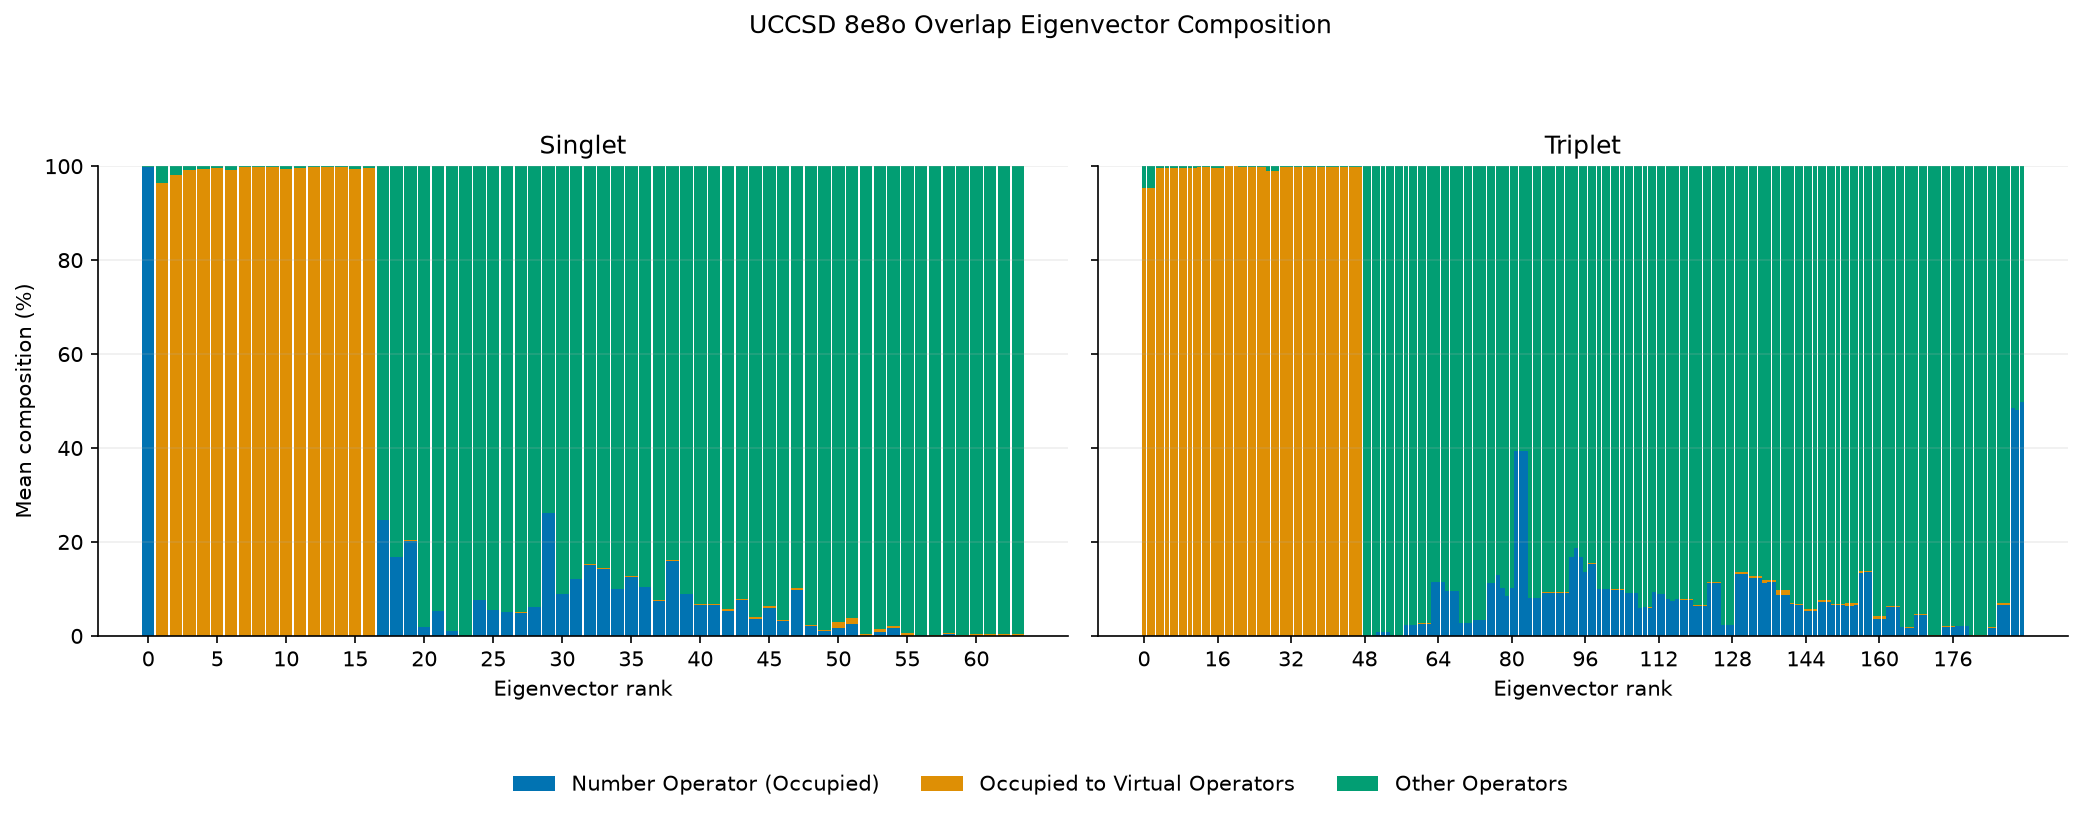

In [4]:
# Get the eigenvector decomposition by classes
composition_categories = ("Number occupied", "OV", "Rest")
eigenvector_composition_data = {}
eigenvector_composition_figures = []

# Separate by active spaces again
for active_space in active_spaces:
    df_uccsd_active = df_uccsd[df_uccsd["active_space"] == active_space]
    # For every active space, first get the operator categories 
    # Enumerate all possible operators in order, then classify them
    singlet_operators, triplet_operators = get_qse_operators(active_space)
    singlet_categories, _ = get_operator_labels(singlet_operators, active_space)
    triplet_categories, _ = get_operator_labels(triplet_operators, active_space)
    operator_categories = {
        "singlet": np.asarray(singlet_categories),
        "triplet": np.asarray(triplet_categories),
    }
    composition_data = {}

    for expansion, categories in operator_categories.items():
        df_expansion = df_uccsd_active[df_uccsd_active["expansion"] == expansion]
        molecule_compositions = []

        # Diagonalise S, get the eigenvectors this time
        for S in df_expansion["S"]:
            _, eigenvectors = la.eigh(np.asarray(S, dtype=complex))
            # Reverse the order of eigenvectors, as they are sorted ascending
            # Here we plot them in descending order 
            # Each weight is normalised such that sum of squares is 1
            component_weights = 100 * np.abs(eigenvectors[:, ::-1]) ** 2
            molecule_compositions.append({
                category: component_weights[categories == category].sum(axis=0)
                for category in composition_categories
            })

        # Take the mean for all 28 molecules
        mean_composition = {
            category: np.mean([composition[category] 
                               for composition in molecule_compositions], axis=0)
            for category in composition_categories
        }
        # Record by different ranks
        composition_data[expansion] = {
            rank: {category: float(mean_composition[category][rank])
                   for category in composition_categories}
            for rank in range(len(categories))
        }

    eigenvector_composition_data[active_space] = composition_data
    figure = plot_eigenvector_composition(composition_data, active_space)
    save_figure(figure, "dimension_analysis/overlap_eigenvector_composition", f"uccsd_{active_space}")
    eigenvector_composition_figures.append(figure)

show_scrollable_figs(eigenvector_composition_figures)


## Threshold vs Stable QSE Dimensions


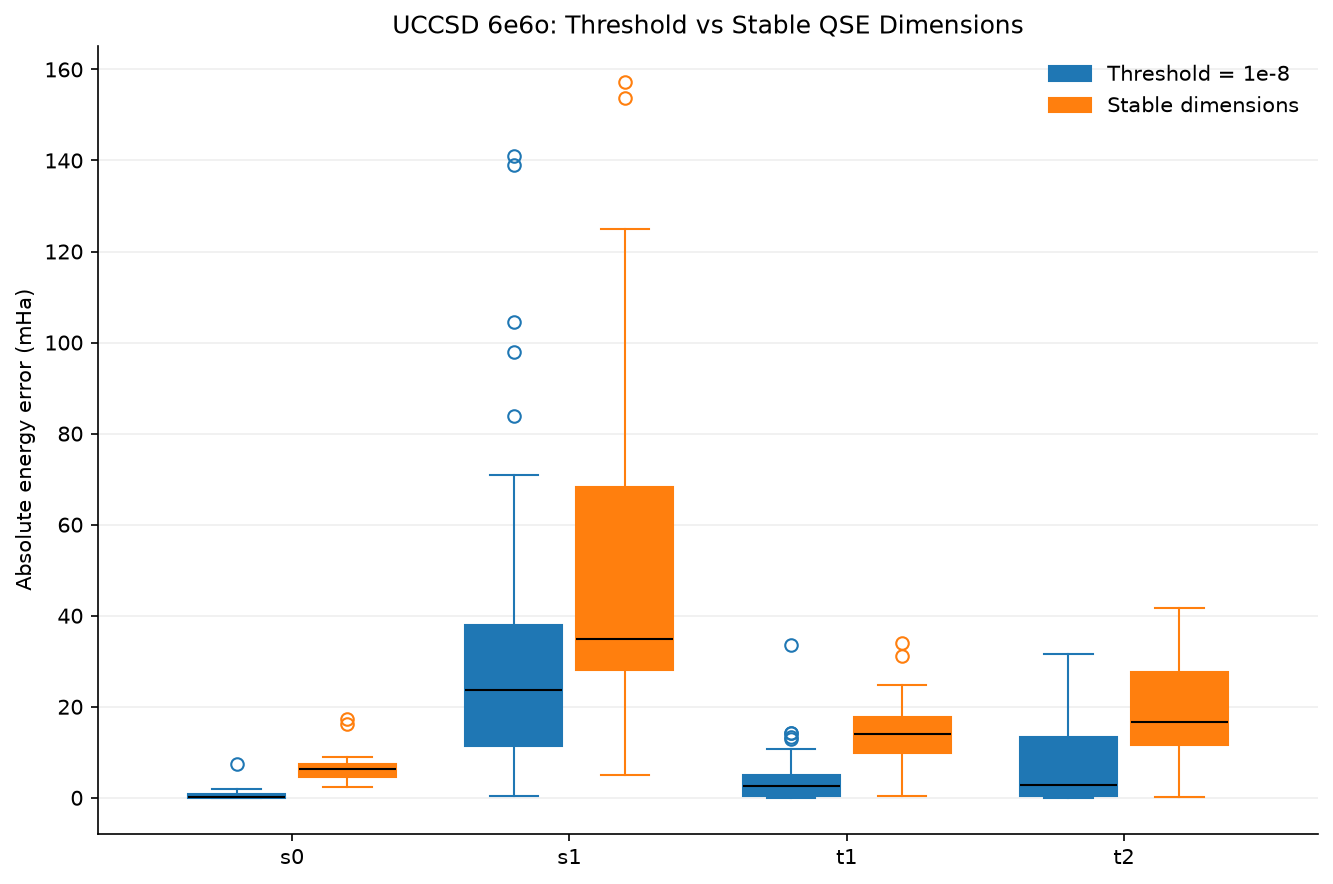

In [5]:
# Compare thresholded and stable-dimension low-state errors.
df_uccsd_6e6o = df_sv[
    (df_sv["ansatz"] == "UCCSD")
    & (df_sv["active_space"] == "6e6o")
]

stable_dimensions = dict(zip(("singlet", "triplet"), get_stable_states((6, 6))))
dimension_errors = defaultdict(lambda: defaultdict(list))

for _, row in df_uccsd_6e6o.iterrows():
    stable_dim = stable_dimensions[row["expansion"]]
    stable_qse_energies, _ = dimension_solve(row["H"], row["S"], stable_dim)

    origin_qse_energies, _ = general_solve(row["H"], row["S"], threshold=1e-8)
    for method, qse_energies in (
        ("threshold", origin_qse_energies),
        ("stable_states", stable_qse_energies),
    ):
        if row["expansion"] == "singlet":
            state_labels = ("s0", "s1")
            qse_energies = qse_energies[:2]
        else:
            state_labels = ("t1", "t2")
            qse_energies = qse_energies[:6].reshape(-1, 3).mean(axis=1)

        for root, state in enumerate(state_labels):
            exact_energy = row["pyscf_casci_energies"][root]
            error = 1000 * abs(qse_energies[root] - exact_energy)
            dimension_errors[method][state].append(error)

figure = plot_dimension_error_distribution(dimension_errors)
save_figure(figure, "dimension_analysis", "threshold_stable_error_distribution_6e6o")
show_scrollable_figs([figure])